# CapacityIQ Exploratory Data Analysis
Data extracts from June 16, 2026

List of new extracts:
1. `change_request for evergreen since 2024-05-01.xlsx`
2. `change_request since 2024-05-01.xlsx`
3. `incident since 2024-05-01.xlsx`
4. `incident_sla.xlsx`
5. `problem since 2024-05-01.xlsx`
6. `Resources COPY.xlsx`
7. `sc_task service requests since 2024-05-01.xlsx`
8. `sys_user_grmember Pod members i.e. managed services resources.xlsx`
9. `time_card_daily since 2024-05-01.xlsx`

Things to note from last conversation with Ivan:
1. Remove LLP from timesheets but assume they are static resources with 144 hours per month allocated.
2. Nespresso - wait for extract from someone

## Import Libraries

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, HTML
import matplotlib.dates as mdates
import warnings
from rapidfuzz import process, fuzz

warnings.filterwarnings("ignore", category=UserWarning, module="openpyxl")

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)

## Compare names and specializations in Paul's sheet versus Ivan's sheet

In [17]:
df_paul = pd.read_excel("resource_comparison.xlsx", sheet_name="paul")
df_ivan = pd.read_excel("resource_comparison.xlsx", sheet_name="ivan")

In [18]:
df_ivan['User'] = df_ivan['User'].str.split(', ').apply(lambda x: f"{x[1]} {x[0]}" if len(x) == 2 else x[0])

In [19]:
def match_names(df1, df2, col1, col2):
    matches = []

    user_list = df2[col1].dropna().tolist()

    for name in df1[col2].dropna():
        match, score, _ = process.extractOne(
            name,
            user_list,
            scorer=fuzz.ratio
        )
        matches.append((name, match, score))

    return pd.DataFrame(matches, columns=['Name', 'Closest Match', 'Similarity'])

THRESHOLD = 50

result_ivan = match_names(df_ivan, df_paul, "User", "User").sort_values(by="Similarity", ascending=True)
display(result_ivan[result_ivan["Similarity"]<THRESHOLD])

result_paul = match_names(df_paul, df_ivan, "User", "User").sort_values(by="Similarity", ascending=True)
display(result_paul[result_paul["Similarity"]<THRESHOLD])

,Name,Closest Match,Similarity
12,Lucy Nyokabi Kirui,Elora Kar,37.037037
19,Julene Hendricks,Oluwaseun James Peterson,40.000000
44,Koyya Monika,Dalton Diaz Mejia,40.000000
65,Alex Spyrou,Ayodeji Ologun,40.000000
90,Exigy Resources,Neil Pace Cocks,40.000000
118,Tony Rosler,Andrew Maskery,40.000000
116,Keyron Yadirts Guillen Porras,Konduru Sarath Varma,40.816327
41,Devender Ninaniya,Dejan Mijailovic,41.176471
47,Rosie Huckle,Lakshmi Mula,41.666667
101,Noel Aguis,Ayodeji Ologun,41.666667


,Name,Closest Match,Similarity
37,Widad ElAsly,Abbas Ali Aloc,38.461538
25,Sravan Boini,Boini Sravan Kumar,46.666667


## Load Data

In [20]:
def read_sheets(filename):
    """Read the input data"""
    sheets = pd.read_excel(filename, sheet_name=None)
    df = pd.concat(sheets.values(), ignore_index=True)
    return df.shape, df

df_evergreen_shape, df_evergreen = read_sheets("change_request for evergreen since 2024-05-01.xlsx")
print(f"Evergreen shape: {df_evergreen_shape}")

df_cr_shape, df_cr = read_sheets("change_request since 2024-05-01.xlsx")
print(f"Change requests shape: {df_cr_shape}")

df_inc_shape, df_inc = read_sheets("incident since 2024-05-01.xlsx")
print(f"Incidents shape: {df_inc_shape}")

df_inc_sla_shape, df_inc_sla = read_sheets("incident_sla.xlsx")
print(f"Incidents SLA shape: {df_inc_sla_shape}")

df_prob_shape, df_prob = read_sheets("problem since 2024-05-01.xlsx")
print(f"Problems shape: {df_prob_shape}")

df_sr_shape, df_sr = read_sheets("sc_task service requests since 2024-05-01.xlsx")
print(f"SR shape: {df_sr_shape}")

df_pods_shape, df_pods = read_sheets("sys_user_grmember Pod members i.e. managed services resources.xlsx")
print(f"Pods shape: {df_pods_shape}")

df_time_shape, df_time = read_sheets("time_card_daily since 2024-05-01.xlsx")
print(f"Time shape: {df_time_shape}")

Evergreen shape: (17, 10)
Change requests shape: (959, 33)
Incidents shape: (6020, 43)
Incidents SLA shape: (10260, 25)
Problems shape: (35, 14)
SR shape: (1261, 15)
Pods shape: (81, 4)
Time shape: (100000, 7)


In [21]:
df_inc['Assigned to'].unique()

array(['Chiamaka Joy Ichoku', 'Chinedu Augustine Muoneke',
       'Vaibhav Vinayak Sane', 'Jomer Majadas Sanosa',
       'Yasmin Farouk Mostafa Abdelaziz', 'Opeyemi Olaitan Alabi',
       'Paul Caruana', 'Valentina Sabogal Gonzalez', 'Dejan Mijailovic',
       'Apurva Bansal', 'Christian Borg', 'Sayak Chattopadhyay',
       'Kim Shimabukuro Matos', 'Marco Mizzi', 'Mario Gauci',
       'Lalit Murlidhar Jivnani', 'Ravi Ranjan', 'Rosie Huckle',
       'Eric Vella', 'Muhammad Umair Zahid', 'Klevis Dedaj',
       'Joseph Pellicano', 'Uzair Mansuri', 'Stephanie Zammit',
       'Darren Micallef', 'Francesco Grech', 'Manju Meruva',
       'Dennis Riolo', 'Alisha Kalan', 'Andrew Maskery', 'Joey Pascual',
       'Neil Pace Cocks', 'Abhijay Joshi', 'Lakshmi Mula',
       'Luisa Mia Peralta', 'Yemi Kuti', 'Richelle Rivera Miralles',
       'VenkataKrishna Chunchu', 'Lisa Court', 'Sadri Salihu',
       'Clayton Saliba', 'Kadali Santosh', 'Oluwaseun James Peterson',
       'Widad ElAsly', nan, 'Berk

In [22]:
df_time["User"].unique()

array(['Valentina Sabogal Gonzalez', 'Uzair Mansuri', 'Clayton Saliba',
       'Joey Pascual', 'Chiamaka Joy Ichoku', 'Chinedu Augustine Muoneke',
       'Vaibhav Vinayak Sane', 'Sue Harrington', 'Charles Peter Dixon',
       'Paul Caruana', 'Muhammad Umair Zahid', 'Eric Vella', 'Aditi Sood',
       'Opeyemi Olaitan Alabi', 'Lisa Court', 'Lalit Murlidhar Jivnani',
       'Neil Pace Cocks', 'Joseph Pellicano', 'Nicola Lynch',
       'Matthew Borg Cardona', 'Mujidat Fikayo Jimoh',
       'Ivan Louis Carabott', 'Sai Anumolu', 'Dejan Mijailovic',
       'Luisa Mia Peralta', 'Apurva Bansal', 'Vikranth B', 'Dennis Riolo',
       'Nikki Xuereb Conti', 'Ranjithkumar Ponnusamy',
       'Rajani Jamgamgunta', 'Stephanie Zammit', 'Mannan Aftab',
       'Mario Gauci', 'Kim Shimabukuro Matos', 'Christian Borg',
       'Manju Meruva', 'Darren Micallef', 'Francesco Grech',
       'Marco Mizzi', 'Jomer Majadas Sanosa',
       'Yasmin Farouk Mostafa Abdelaziz', 'SyedKhurram Mehdi',
       'Shimera Manil

In [23]:
import pandas as pd

# Combine unique names
all_names = pd.DataFrame({
    'Name': pd.unique(df_inc['Assigned to'].tolist() + df_time['User'].tolist())
})

# Create a single column with labels
def classify(name):
    in_inc = name in set(df_inc['Assigned to'])
    in_time = name in set(df_time['User'])
    
    if in_inc and in_time:
        return 'Both'
    elif in_inc:
        return 'Incident'
    else:
        return 'TimeTable'

all_names['Source'] = all_names['Name'].apply(classify)

all_names

C:\Users\kvillaera\AppData\Local\Temp\ipykernel_22488\3714373839.py:5: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  'Name': pd.unique(df_inc['Assigned to'].tolist() + df_time['User'].tolist())


,Name,Source
0,Chiamaka Joy Ichoku,Both
1,Chinedu Augustine Muoneke,Both
2,Vaibhav Vinayak Sane,Both
3,Jomer Majadas Sanosa,Both
4,Yasmin Farouk Mostafa Abdelaziz,Both
5,Opeyemi Olaitan Alabi,Both
6,Paul Caruana,Both
7,Valentina Sabogal Gonzalez,Both
8,Dejan Mijailovic,Both
9,Apurva Bansal,Both


In [24]:
all_names.to_csv("inc_tc.csv")

## Data Quality

In [25]:
def data_cleanliness_summary(df, name):
    summary = pd.DataFrame({
        "dtype": df.dtypes,
        "non_null_count": df.notnull().sum(),
        "null_count": df.isnull().sum(),
        "null_pct": (df.isnull().mean() * 100).round(2),
        "unique_values": df.nunique()
    })

    # make column names the index
    summary.index.name = "column"

    # sort by most missing
    summary = summary.sort_values(by="null_pct", ascending=False)

    print(f"==== {name.upper()} COLUMN SUMMARY ====")
    display(summary)
    print("")

    duplicates = df[df.duplicated(keep=False)].sort_values(by=df.columns.tolist())

    if len(duplicates) > 0:
        print("\n==== Duplicate Rows ====")
        print(f"Number of duplicates: {len(duplicates)}")
        display(duplicates)
        duplicates.to_csv("duplicates.csv", index=False)

    return summary

In [26]:
dfs = {
    "evergreen": df_evergreen,
    "change requests": df_cr,
    "incidents": df_inc,
    "incidents sla": df_inc_sla,
    "problems": df_prob,
    "service requests": df_sr,
    "pods": df_pods,
    "time card": df_time
}

In [27]:
for i in dfs:
    data_cleanliness_summary(dfs[i], i)

==== EVERGREEN COLUMN SUMMARY ====


,dtype,non_null_count,null_count,null_pct,unique_values
column,,,,,
Actual end date,datetime64[ns],15,2,11.76,15
Actual start date,datetime64[ns],15,2,11.76,15
Planned start date,datetime64[ns],16,1,5.88,16
Planned end date,datetime64[ns],16,1,5.88,16
Short description,object,17,0,0.00,3
Number,object,17,0,0.00,17
State,object,17,0,0.00,3
Assigned to,object,17,0,0.00,7
Business service,object,17,0,0.00,11



==== CHANGE REQUESTS COLUMN SUMMARY ====


,dtype,non_null_count,null_count,null_pct,unique_values
column,,,,,
Other information,object,51,908,94.68,49
Change implementation sign off date,datetime64[ns],354,605,63.09,354
Close notes,object,444,515,53.70,291
Close code,object,447,512,53.39,4
Customer approval of estimate date,datetime64[ns],470,489,50.99,470
Current State of Play,object,536,423,44.11,311
Total quoted effort in hours,float64,596,363,37.85,121
Estimate,object,601,358,37.33,560
Estimate breakdown (Not customer visible),object,637,322,33.58,601



==== INCIDENTS COLUMN SUMMARY ====


...

,dtype,non_null_count,null_count,null_pct,unique_values
column,,,,,
Group,object,81,0,0.0,16
User,object,81,0,0.0,81
Email,object,81,0,0.0,81
Specialisation,object,81,0,0.0,6



==== TIME CARD COLUMN SUMMARY ====


,dtype,non_null_count,null_count,null_pct,unique_values
column,,,,,
Task,object,77097,22903,22.9,6091
Company,object,77097,22903,22.9,43
Date,datetime64[ns],100000,0,0.0,576
User,object,100000,0,0.0,142
Category,object,100000,0,0.0,13
Time worked,float64,100000,0,0.0,150
Rate type,object,100000,0,0.0,8




==== Duplicate Rows ====
Number of duplicates: 111


column,Date,User,Task,Company,Category,Time worked,Rate type
3029,2024-05-29,Manju Meruva,INC0026592,The Care Quality Commission,Task work,2.00,Normal Billable
3085,2024-05-29,Manju Meruva,INC0026592,The Care Quality Commission,Task work,2.00,Normal Billable
3201,2024-05-30,Manju Meruva,INC0026592,The Care Quality Commission,Task work,2.00,Normal Billable
3203,2024-05-30,Manju Meruva,INC0026592,The Care Quality Commission,Task work,2.00,Normal Billable
3326,2024-05-31,Manju Meruva,INC0026592,The Care Quality Commission,Task work,2.00,Normal Billable
3331,2024-05-31,Manju Meruva,INC0026592,The Care Quality Commission,Task work,2.00,Normal Billable
8207,2024-07-12,Francesco Grech,NaN,NaN,Internal meeting,1.00,Normal Billable
8270,2024-07-12,Francesco Grech,NaN,NaN,Internal meeting,1.00,Normal Billable
12411,2024-08-14,Ivan Louis Carabott,NaN,NaN,Internal meeting,2.00,Normal Billable
12560,2024-08-14,Ivan Louis Carabott,NaN,NaN,Internal meeting,2.00,Normal Billable


## Exploratory Data Analysis

### User mismatches between Incident, Resources, and Pod

In [28]:
df_inc["User_true"] = df_inc["Assigned to"]
df_inc["User_true"].head(3)

0          Chiamaka Joy Ichoku
1    Chinedu Augustine Muoneke
2    Chinedu Augustine Muoneke
Name: User_true, dtype: object

In [29]:
df_ivan["Email"] = df_ivan["Email"].str.lower()
df_paul["Email"] = df_paul["Email"].str.lower()

In [31]:
df_merged = df_ivan.merge(df_paul, on="Email", how="left")
df_merged.rename(columns={
    "User_x": "User_true",
    "Pod": "Ivan_Pod",
    "User_y": "Paul_Name",
    "Group": "Paul_Pod"
}
, inplace=True)
df_merged = df_merged.merge(df_inc[["User_true"]], on="User_true", how="outer", indicator=True)
#df_merged.drop(["Paul", "Email"], axis=1, inplace=True)
df_merged.sort_values(by="_merge", inplace=True)

In [32]:
df_merged.drop_duplicates(inplace=True)

In [33]:
df_merged.rename(columns={
    "User_true": "User",
    "_merge": "Found in"
}
, inplace=True)
df_merged.drop(["Ivan_Pod", "Paul_Name", "Paul_Pod"], axis=1, inplace=True)

In [35]:
mapping = {
    "left_only": "Ivan or Paul's sheet",
    "right_only": "Incident sheet",
    "both": "both"
}
df_merged["Present"] = df_merged["Found in"].map(mapping)
df_merged.drop(["Found in"], axis=1, inplace=True)

In [ ]:
names_to_remove = ["Amit Kumar Singh", "Amit Singh", "Andrew Maskery", "Andy Maskery",
                   "Argellie Monique G Perdigon", "Argellie Perdigon", "Devender Ninaniya", "Devender  Ninaniya",
                   "Ivan Carabott", "Ivan Louis Carabott", "Jomer Majadas Sanosa", "Jomer Sanosa", "Luisa Mia Hernandez Peralta",
                   "Luisa Mia Peralta", "Madeva Mallegowda", "Sumukh Veacham Ramkumar", "Sumukh VeachamRamkumar", "Santhoshkumari T", "Sumukh VeachamRamkumar",
                   "Venkata Krishna Chunchu", "VenkataKrishna Chunchu", "Richelle Rivera Miralles", "Richelle Miralles", ""
                ]
df_filtered = df_merged[~df_merged['User'].isin(names_to_remove)]
df_filtered.sort_values(by="User")

,User,Email,Present
0,Abbas Ali Aloc,abbasali.aloc@kpmg.co.uk,Ivan or Paul's sheet
28,Abdul Rahman,NaN,Incident sheet
40,Abela Eman,eman.abela@kpmg.co.uk,Ivan or Paul's sheet
109,Abhijay Joshi,NaN,Incident sheet
136,Abhijeet Biswas,NaN,Incident sheet
140,Abhishek Sinha,NaN,Incident sheet
152,Abhishek Tripathy,abhishek.tripathy@kpmg.co.uk,both
153,Adriano Sigona,adriano.sigona@kpmg.co.uk,Ivan or Paul's sheet
154,Ailsa Thompson,NaN,Incident sheet
174,Akash Kulkarni,NaN,Incident sheet


In [47]:
df_filtered.to_csv("AAA.csv")

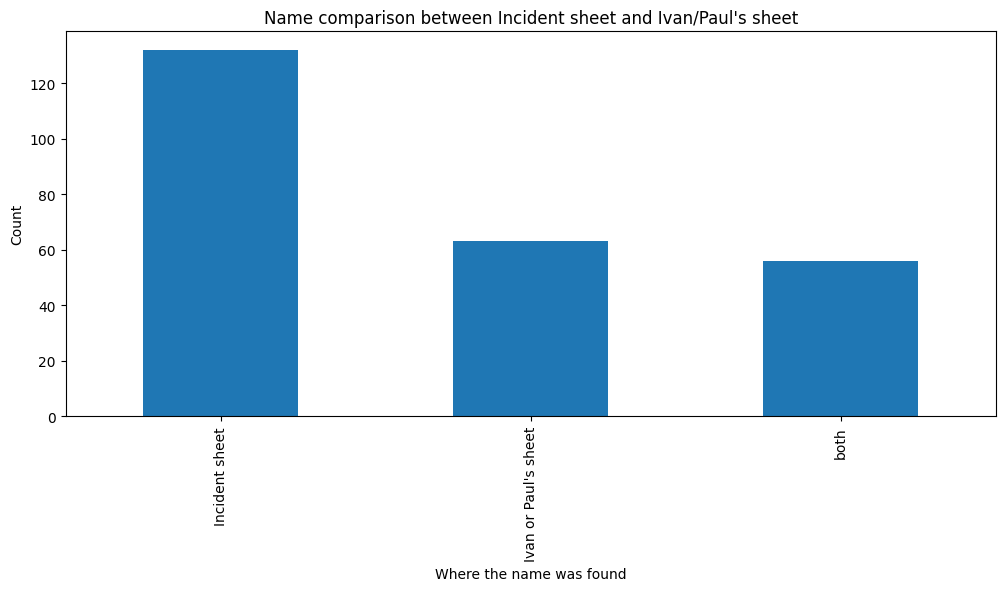

In [94]:
plt.figure(figsize=(12, 5))
df_merged["Present"].value_counts().plot(kind="bar")
plt.title("Name comparison between Incident sheet and Ivan/Paul's sheet")
plt.xlabel("Where the name was found")
plt.ylabel("Count")
plt.show()

In [95]:
df_merged["Present"].value_counts()

Present
Incident sheet          132
Ivan or Paul's sheet     63
both                     56
Name: count, dtype: int64

In [92]:
df_merged

,User,Present
0,Abbas Ali Aloc,Ivan or Paul's sheet
1501,Exigy Resources,Ivan or Paul's sheet
3389,Mark Anthony Busuttil,Ivan or Paul's sheet
3724,Muhammad Wasim Abbas,Ivan or Paul's sheet
40,Abela Eman,Ivan or Paul's sheet
819,Carlos Dalton Diaz Mejia,Ivan or Paul's sheet
5042,Soniya Balakrishna Shet,Ivan or Paul's sheet
3394,Matthew Xuereb,Ivan or Paul's sheet
4228,Ranjithkumar Ponnusamy,Ivan or Paul's sheet
2284,Karishma Shaik,Ivan or Paul's sheet


In [91]:
df_merged.to_csv("Discrepancies between INC, Resources, and Pods.csv", index=False)

### Evergreen

In [ ]:
df_evergreen.head(3)

column,Number,Short description,Company,Business service,Assigned to,State,Planned start date,Planned end date,Actual start date,Actual end date
0,CHG0033951,Evergreen: Microsoft Dynamics CE Service Update,Indurent Limited,Indurent CE Changes,Christian Borg,New,NaT,NaT,NaT,NaT
1,CHG0033950,Evergreen: Microsoft Dynamics CE Service Update,KPMG Norway,KPMG Norway CE Support,Christian Borg,Closed,2026-03-24 07:57:32,2026-03-24 07:58:01,2026-04-23 07:58:21,2026-04-23 07:58:27
2,CHG0033949,Evergreen: Microsoft Dynamics CE Service Update,KPMG Ireland,KPMG Ireland CE Support,Christian Borg,Closed,2026-03-01 09:42:13,2026-04-15 09:43:13,2026-04-15 09:44:06,2026-04-15 09:49:26


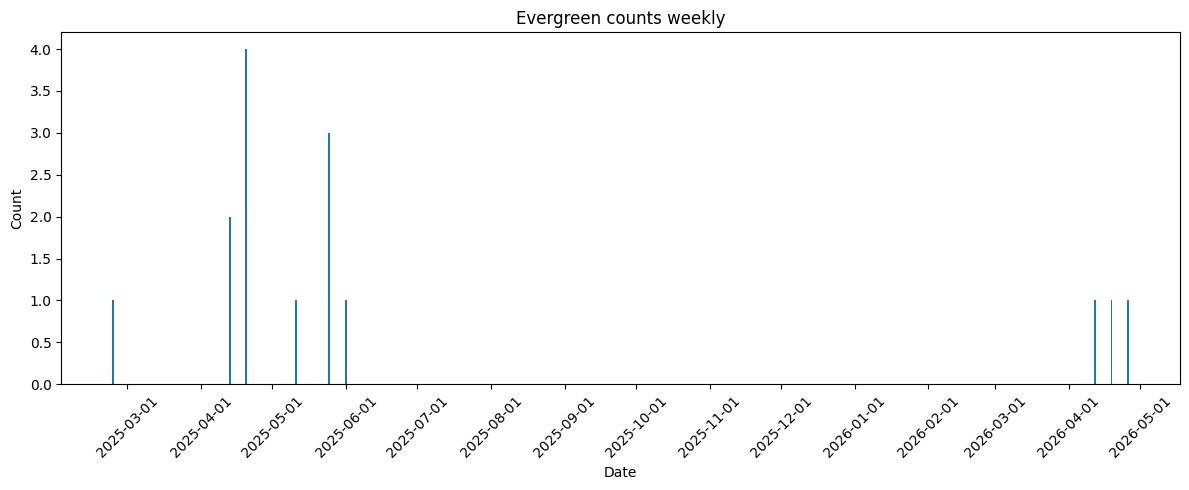

In [ ]:
df_evergreen["Actual start date"] = pd.to_datetime(df_evergreen["Actual start date"])

evergreen_weekly = (
    df_evergreen.set_index("Actual start date")
    .resample("W")
    .size()
)
evergreen_weekly.index = pd.to_datetime(evergreen_weekly.index)

plt.figure(figsize=(12, 5))

plt.bar(evergreen_weekly.index, evergreen_weekly.values)

plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))

plt.xticks(rotation=45)
plt.title("Evergreen counts weekly")
plt.xlabel("Date")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

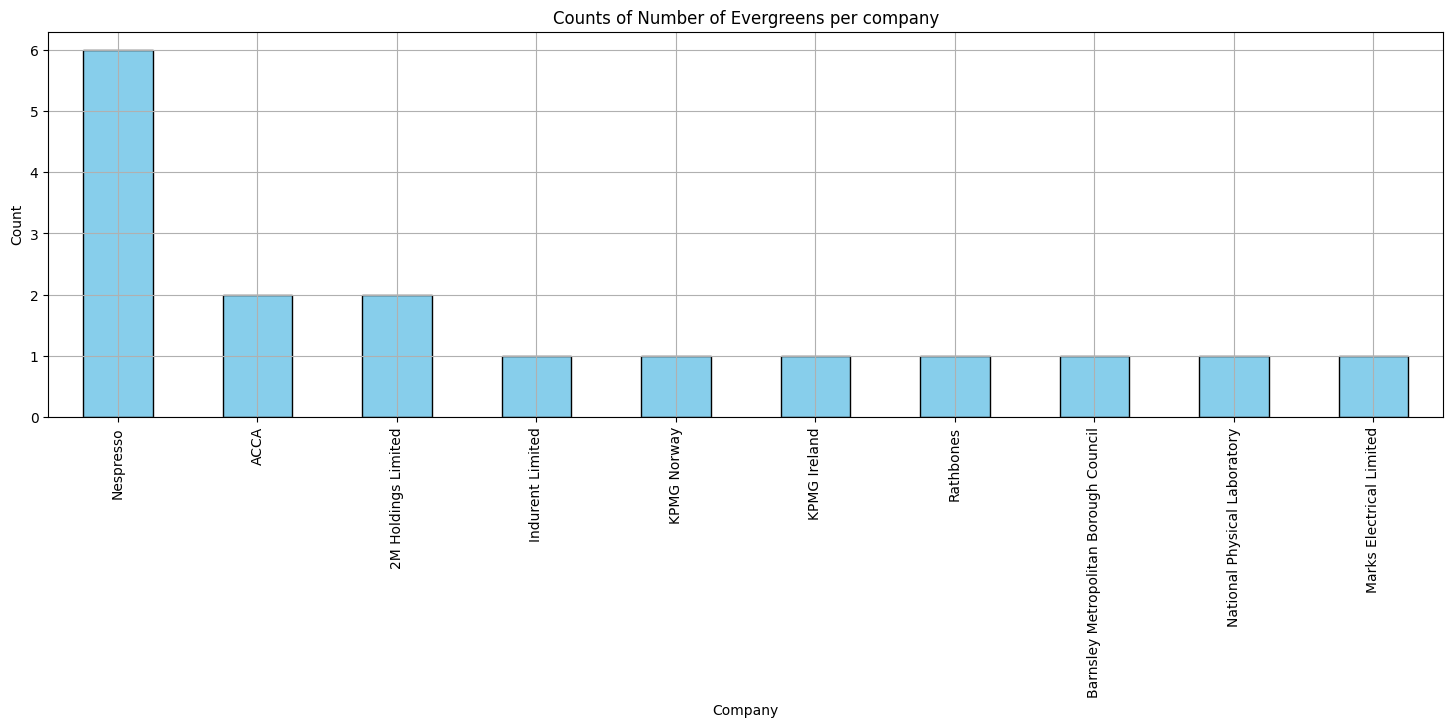

In [ ]:
def plot_simple_bar(df, column, name):
    df[column].value_counts().plot(kind="bar", figsize=(18,5), edgecolor="black", color="skyblue")

    plt.title(f"Counts of {name}")
    plt.xlabel(f"{column}")
    plt.ylabel("Count")
    plt.xticks(rotation=90)
    plt.style.use('dark_background')
    plt.grid(True)
    plt.show()

plot_simple_bar(df_evergreen, "Company", "Number of Evergreens per company")

## Change Requests

Filter out canceled tickets

In [ ]:
df_cr = df_cr[df_cr["State"] != "Canceled"]

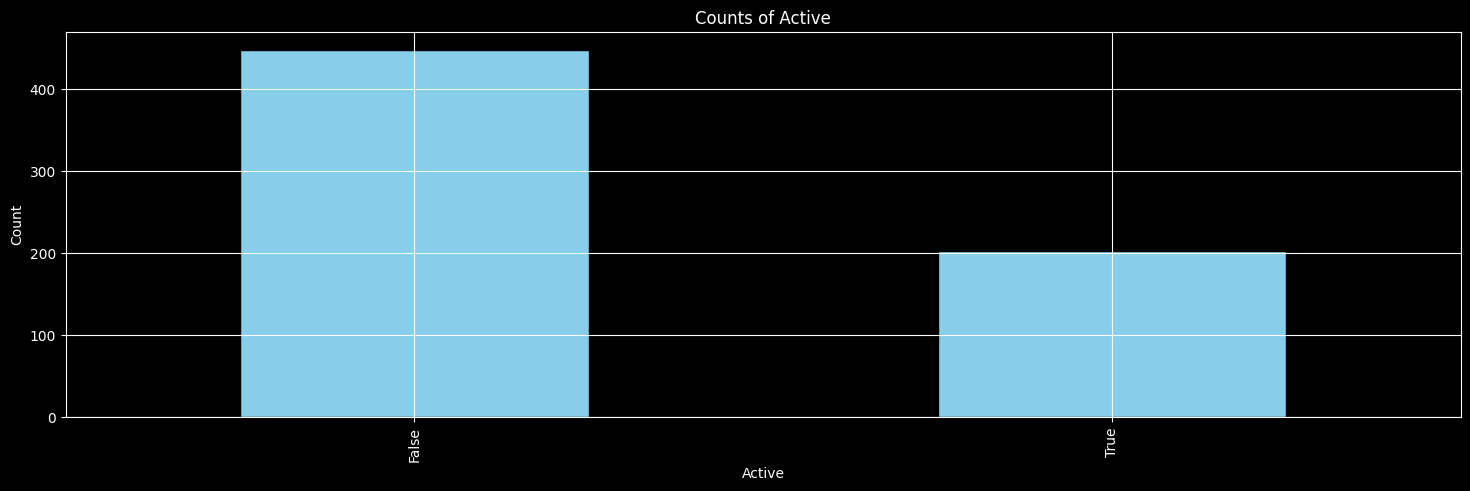

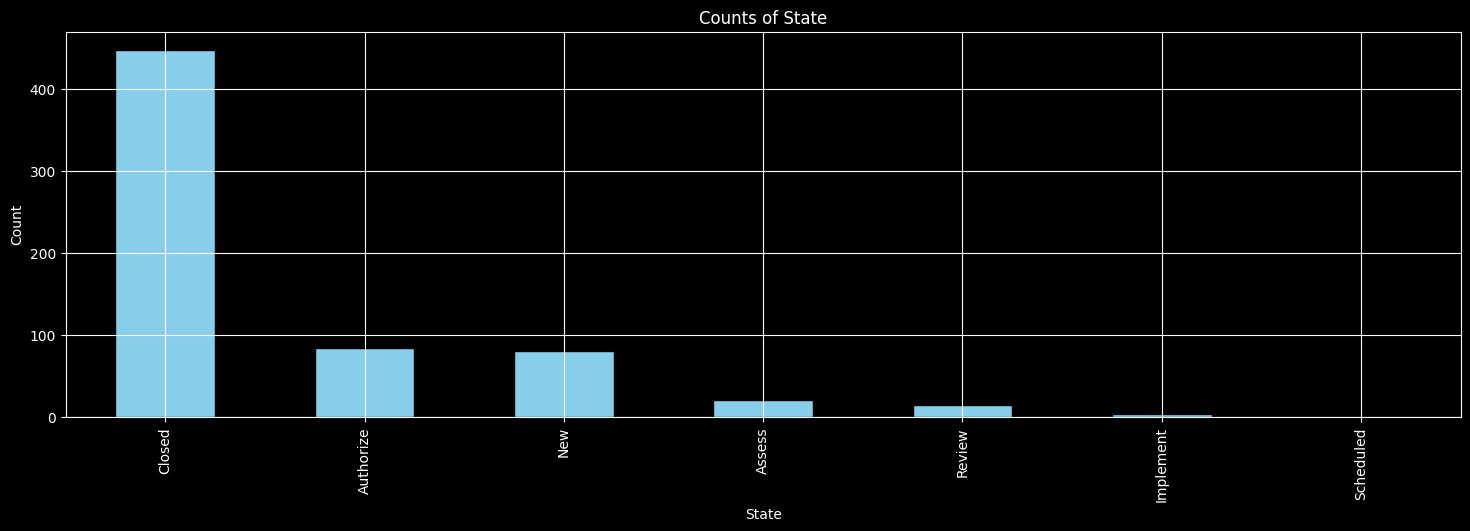

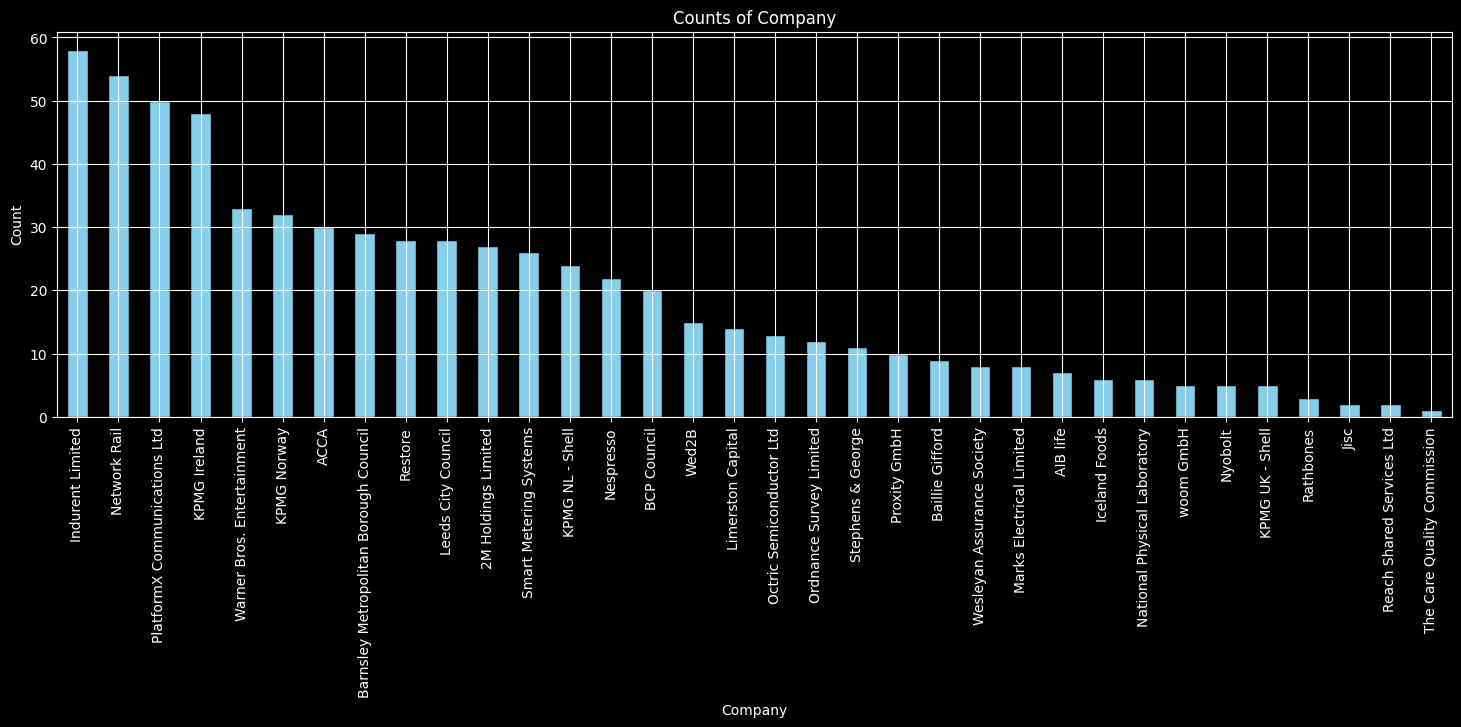

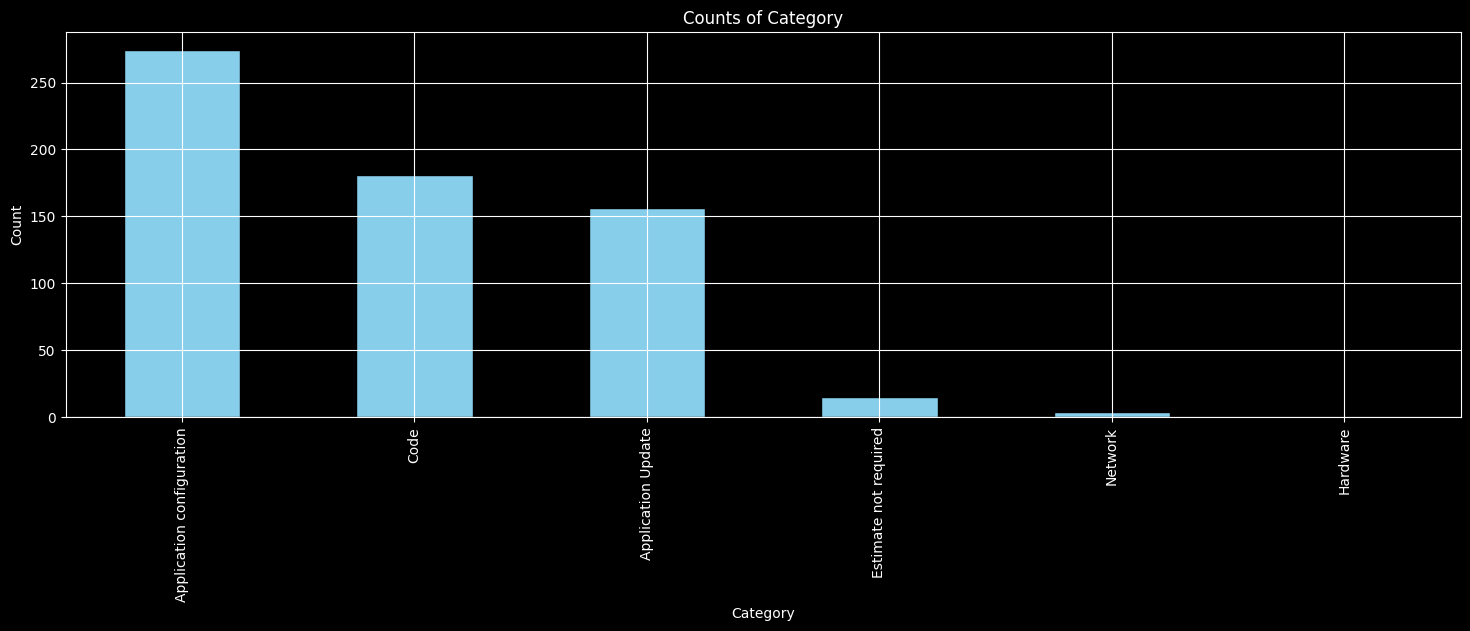

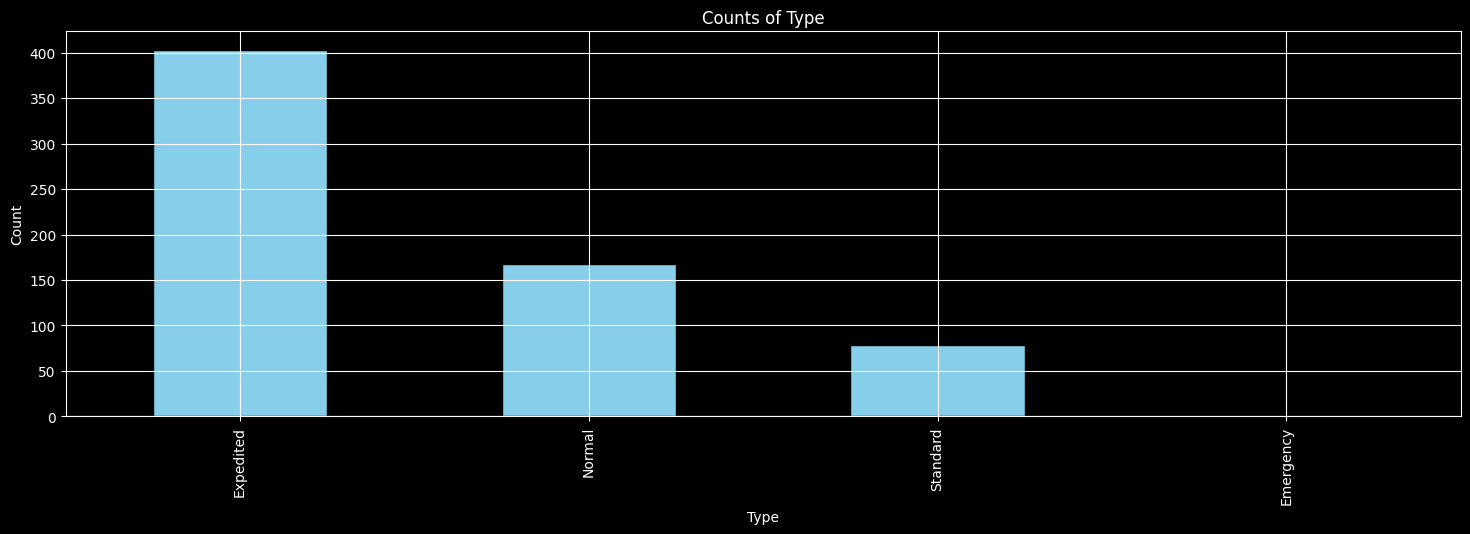

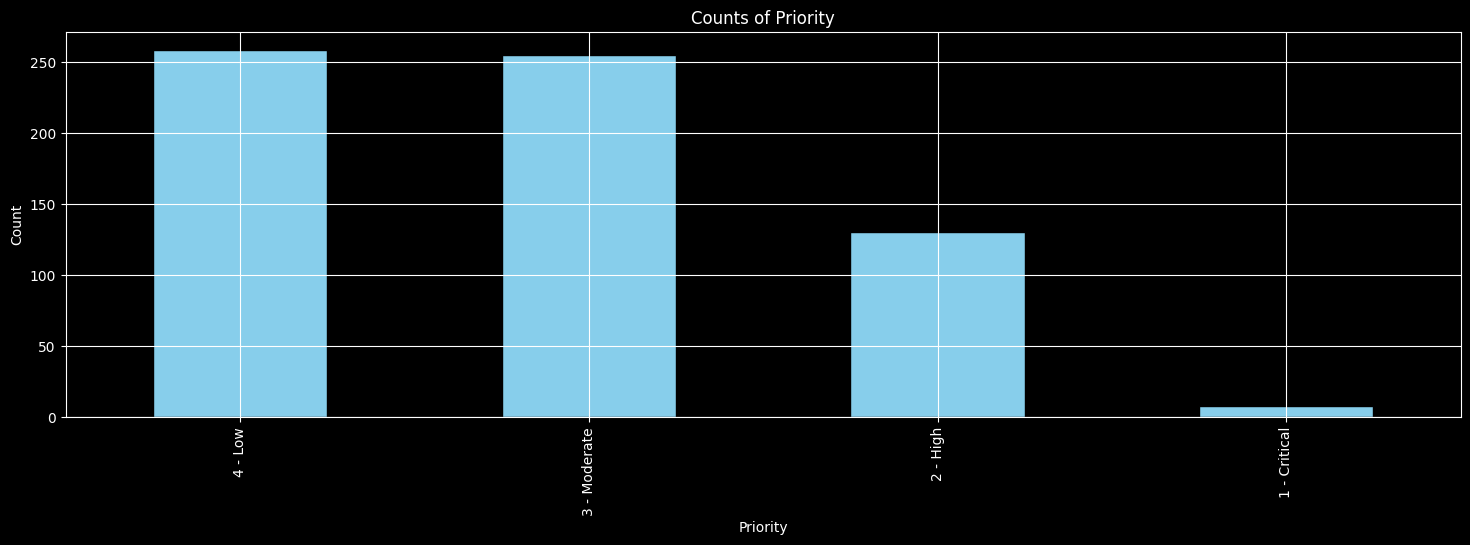

In [ ]:
plot_these_cols = ["Active", "State", "Company", "Category", "Type", "Priority"]

for c in plot_these_cols:
    plot_simple_bar(df_cr, c, c)

Plot duration. Closed - Opened for those wherein both fields are provided.

C:\Users\kvillaera\AppData\Local\Temp\ipykernel_5868\1331714149.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cr["Opened"] = pd.to_datetime(df_cr["Opened"])
C:\Users\kvillaera\AppData\Local\Temp\ipykernel_5868\1331714149.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cr["Closed"] = pd.to_datetime(df_cr["Closed"])
C:\Users\kvillaera\AppData\Local\Temp\ipykernel_5868\1331714149.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row

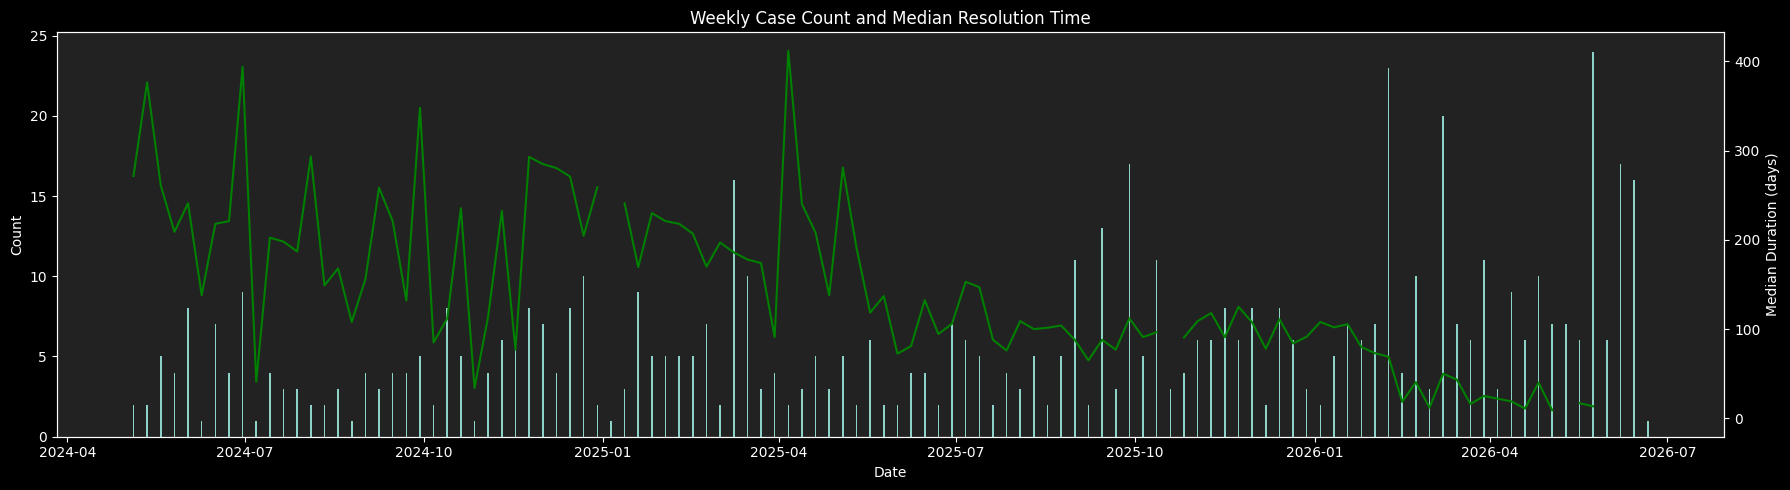

In [ ]:
# ensure datetime
df_cr["Opened"] = pd.to_datetime(df_cr["Opened"])
df_cr["Closed"] = pd.to_datetime(df_cr["Closed"])

# duration in days
df_cr["Duration"] = (df_cr["Closed"] - df_cr["Opened"]).dt.days

# weekly aggregations
weekly_count = (
    df_cr.set_index("Opened")
    .resample("W")
    .size()
)

weekly_duration = (
    df_cr.set_index("Opened")
    .resample("W")["Duration"]
    .median()
)

fig, ax1 = plt.subplots(figsize=(18, 5))

# bars = count
ax1.bar(weekly_count.index, weekly_count.values)
ax1.set_ylabel("Count")
ax1.set_xlabel("Date")

# second axis = duration
ax2 = ax1.twinx()
ax2.plot(weekly_duration.index, weekly_duration.values, color="green")
ax2.set_ylabel("Median Duration (days)")

ax1.set_facecolor("#222222") 
ax2.set_facecolor("#222222") 
plt.style.use('dark_background')


plt.xticks(rotation=90)
plt.title("Weekly Case Count and Median Resolution Time")

plt.tight_layout()
plt.show()

Why are the durations so high?

In [ ]:
df_cr.sort_values(by="Duration", ascending=False)[:20]

column,Number,Active,Company,Category,Business service,Short description,Description,Total quoted effort in hours,Updated,Current State of Play,Opened by,Assigned to,Opened,Closed,State,Customer approval of estimate,Customer approval of estimate date,Engagement leader approval,Change implementation sign off,Change implementation sign off date,Priority,Implementation plan,Backout plan,Risk and impact analysis,UAT sign-off,Requested by,Estimate,Estimate breakdown (Not customer visible),Configuration item,Type,Close code,Close notes,Other information,Duration
294,CHG0032816,False,KPMG Norway,Application configuration,KPMG Norway CE Support,Win probability,Can you please provide an estimate on setting ...,22.0,2026-04-07 09:18:23,Awaiting Closure (deployed in Test),Pernille Brown,Francesco Grech,2024-06-26 14:18:29,2026-04-07 09:18:23,Closed,True,2024-08-19 14:14:59,Approved,False,NaT,3 - Moderate,Create a cloud flow that will trigger on BPF s...,turn off the cloud flow,no risk,Approved,Pernille Brown,"22 hours including analysis, development, test...",Analysis - 4hrs\nDevelopment - 10hrs\nTest - 3...,KPMG Norway CRM,Expedited,Successful,.,NaN,649.0
194,CHG0033116,False,BCP Council,Code,BCP FO Support,Created from Incident INC0029081 - National Fr...,The 2024 NFI return is due to be run on Monday...,10.0,2026-05-12 10:20:22,awaiting client to close,Lisa Court,Daniel Gustavo Espinoza Valdiviezo,2024-11-19 11:07:42,2026-05-12 10:20:22,Closed,True,2025-04-14 15:12:29,Approved,True,2026-05-12 10:14:53,3 - Moderate,TBC,TBC,TBC,Approved,Steve Cottrell,"The total time for analysis, development, test...",Development: 8hrs\nDeployment: 2hrs\nTotal: 10hrs,Finance General Ledger,Expedited,Successful,report working successfully on prod via paymen...,NaN,538.0
507,CHG0032815,False,KPMG Norway,Application configuration,KPMG Norway CE Support,Notification when opportunity est. sign date h...,Can you please provide an estimate for setting...,21.0,2025-11-14 20:54:39,On Hold by Client (deployed to Test),Pernille Brown,Francesco Grech,2024-06-26 14:13:25,2025-11-14 20:54:39,Closed,True,2024-08-19 14:14:23,Approved,True,2025-10-16 15:26:57,3 - Moderate,Create a flag field in opportunity (check if a...,uninstall solution and turn off cloud flow,there is no risk,Approved,Pernille Brown,"21 hours including analysis, Development, test...",Analysis - 3hrs\nDevelopment - 10hrs\nTest - 3...,KPMG Norway CRM,Expedited,Rolled back,reverted on Dev and Test,NaN,506.0
576,CHG0032685,False,Wesleyan Assurance Society,Application configuration,Wesleyan FO Changes‬‬‬,Advisor Charge - Non Contingent Charging,Wesleyan need a way to collect and report char...,207.0,2025-09-09 14:27:54,Awaiting Client Approval,Chris Carr,Nicola Lynch,2024-05-07 16:39:41,2025-09-09 14:27:54,Closed,True,2025-07-22 12:44:03,Approved,True,2025-07-22 12:51:37,3 - Moderate,As per the design documents,As per the design documents,As per the design documents,Approved,Chris Carr,"Project Management £3,...","Project Management\n3,000\nIntegration Deliver...",Wesleyan - KPMG Powered Finance (Changes),Expedited,Successful with issues,Successfully implemented - two minor post impl...,NaN,489.0
138,CHG0033243,False,Restore,Code,Restore BC Support,ADF_ Allow Multiple Receipts for the Same Invo...,Modify the pipeline to allow multiple receipts...,20.0,2026-06-03 12:46:45,Can be closed,Luke Reape,Julene Jegels,2025-02-01 09:39:06,2026-06-03 12:46:45,Closed,True,2025-07-16 10:09:54,Approved,False,NaT,3 - Moderate,KPMG will build the change on FQA.\nKPMG will ...,Restore the system from the backup taken prior...,client to carry out regression tests in for t...,Approved,Luke Reape,An estimate 20hrs are required to deliver this...,An estimate 20hrs are required to deliver this...,Restore Microsoft Dynamics BC,Expedited,Successful,Closure confirmed by client,NaN,487.0
137,CHG0033251,False,Restore,Code,Restore BC Support,ADF_Harrow Green_amend the code for the pipeli...,On occasion a document date/posting date

## Incidents

In [ ]:
df_inc.head(3)

column,Number,Company,Business service,Short description,Assigned to,Caller,Opened,Opened by,State,On hold reason,Updated,Updated by,Current state of play,Priority,Watch list,Configuration item,Category,Subcategory,Impact,Urgency,Customer ticket number,Assignment group,Vendor,Vendor ticket number,Current State of Play - Follow up date,DevOps reference,Description,Resolution code,Valid Reopen,Resolution notes,Resolved,Resolved by,Closed,Reopen count,Warranty / Hypercare,Active,Project name,Complexity,Total business elapsed time,Major Incident,Major incident state,Additional comments,Work notes
0,INC0027284,PlatformX Communications Ltd,PlatformX FO Support,Naweed Akhtar - Azure Monitor alert failure e...,Chiamaka Joy Ichoku,Frank Cassidy,2024-05-01 08:27:57,Frank Cassidy,Closed,NaN,2024-05-12 13:00:01,system,Awaiting Caller response,4 - Low,Naweed Akhtar,Cross-Stream,Performance,NaN,3 - Low - Individual,3 - Low - Moderate Response,INC000100702703,FO PlatformX Agents,NaN,NaN,2024-05-02 12:54:09,NaN,"How can we see the file at issue, for Azure Mo...",Solved (Permanently),NaN,As discussed in ticket review the issue has be...,2024-05-02 12:54:09,Muhammad Umair Zahid,2024-05-12 13:00:01,0,False,False,NaN,Low,NaN,False,NaN,2024-05-02 12:54:09 - Muhammad Umair Zahid (Ad...,NaN
1,INC0027285,PlatformX Communications Ltd,PlatformX FO Support,"Arunesh Karunanidhi, - D365 Data migration env...",Chinedu Augustine Muoneke,Frank Cassidy,2024-05-01 09:07:30,Frank Cassidy,Closed,NaN,2024-05-12 13:00:02,system,Awaiting Feedback,4 - Low,NaN,Customisation,Service Request,NaN,3 - Low - Individual,3 - Low - Moderate Response,INC000100702818,FO PlatformX Agents,NaN,NaN,2024-05-02 12:58:10,NaN,Please can you assign this to KPMG managed ser...,Solved (Permanently),NaN,"As discussed in ticket review, the issue has b...",2024-05-02 12:58:11,Muhammad Umair Zahid,2024-05-12 13:00:02,0,False,False,NaN,Low,NaN,False,NaN,2024-05-02 12:58:11 - Muhammad Umair Zahid (Ad...,NaN
2,INC0027286,PlatformX Communications Ltd,PlatformX FO Support,Harry Richardson - 'VAT transactions' report,Chinedu Augustine Muoneke,Frank Cassidy,2024-05-01 09:15:49,Frank Cassidy,Closed,NaN,2024-05-17 11:00:00,system,Awaiting Feedback,4 - Low,NaN,Cross-Stream,Service Request,Change Request,3 - Low - Individual,3 - Low - Moderate Response,INC000100702451,FO PlatformX Agents,NaN,NaN,2024-05-07 10:16:05,NaN,I would like to request for the 'VAT transacti...,A Change was created from this Incident,NaN,Followed up with the user and informed this In...,2024-05-07 10:16:05,Chinedu Augustine Muoneke,2024-05-17 11:00:00,0,True,False,NaN,Low,NaN,False,NaN,2024-05-07 10:16:05 - Chinedu Augustine Muonek...,NaN


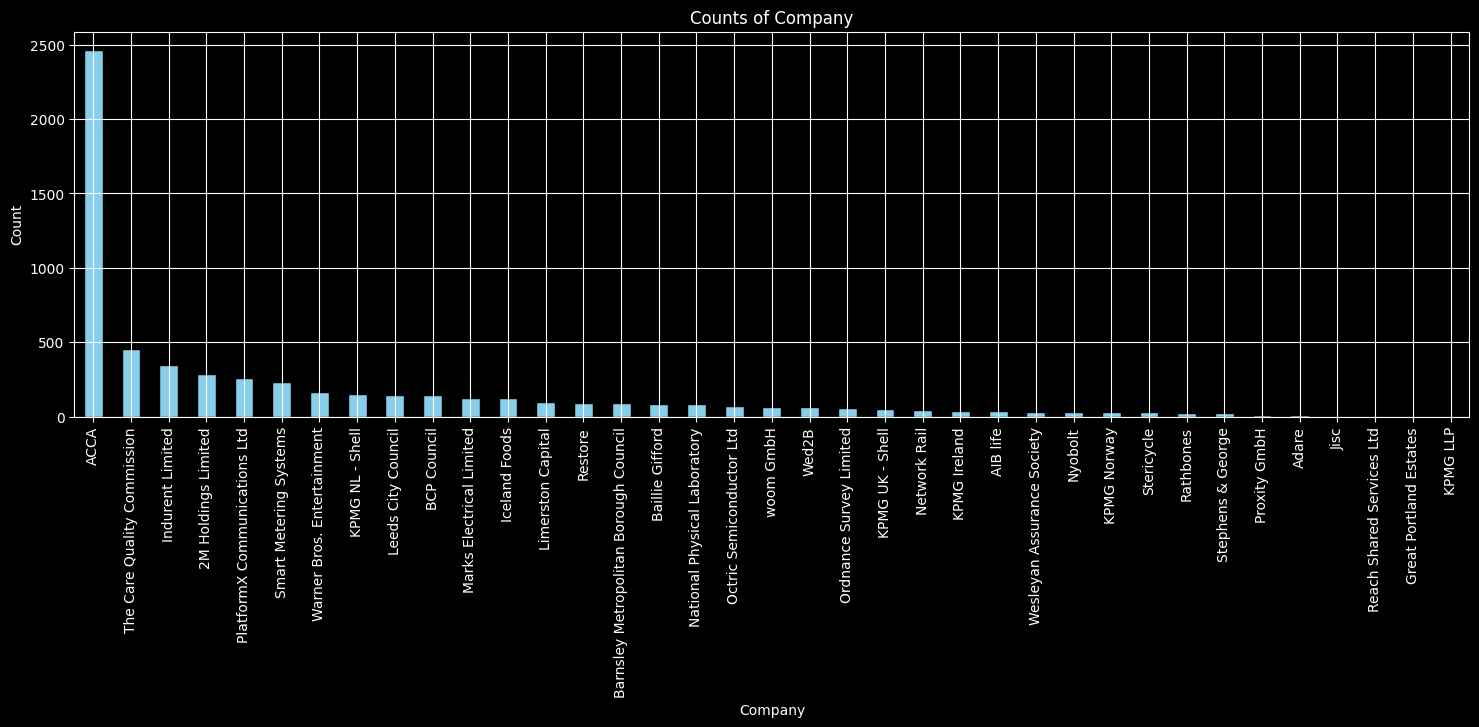

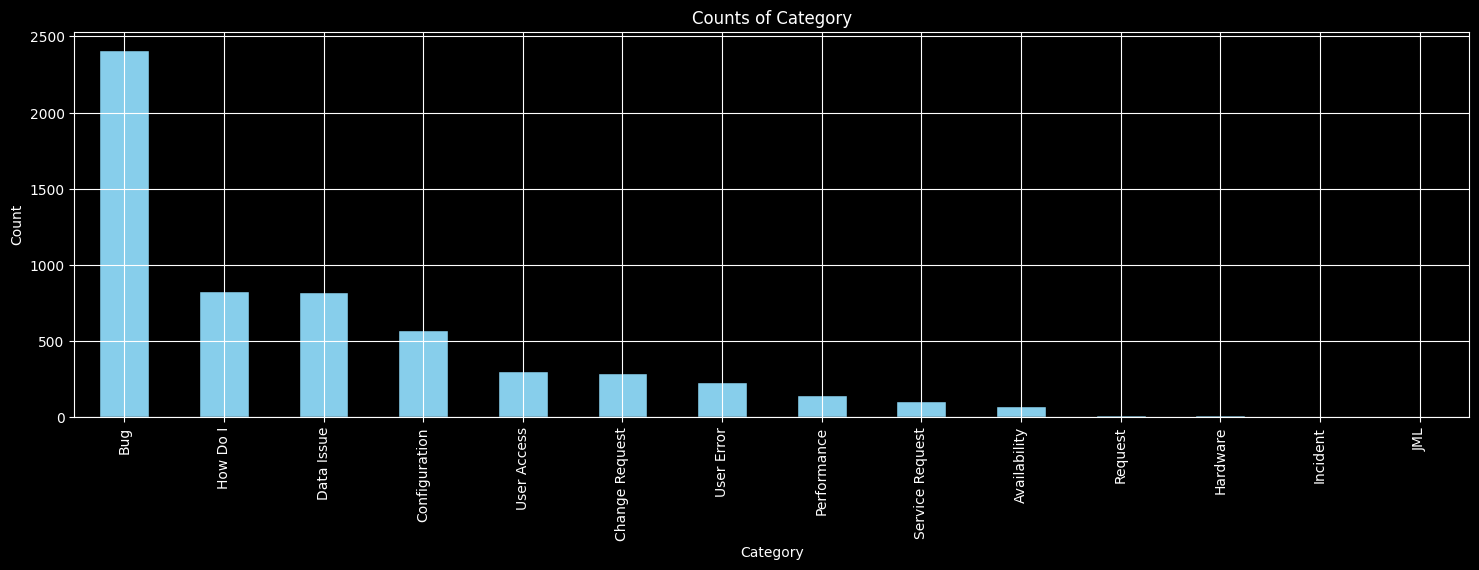

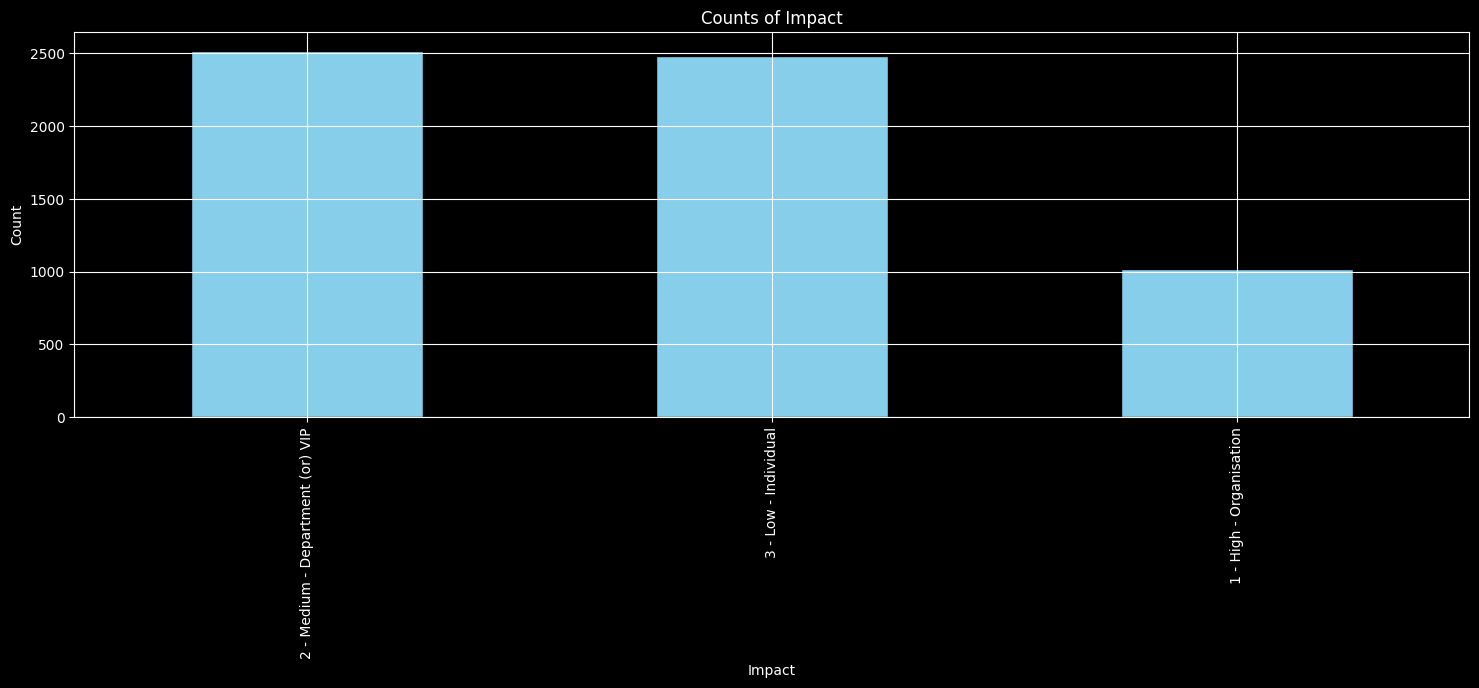

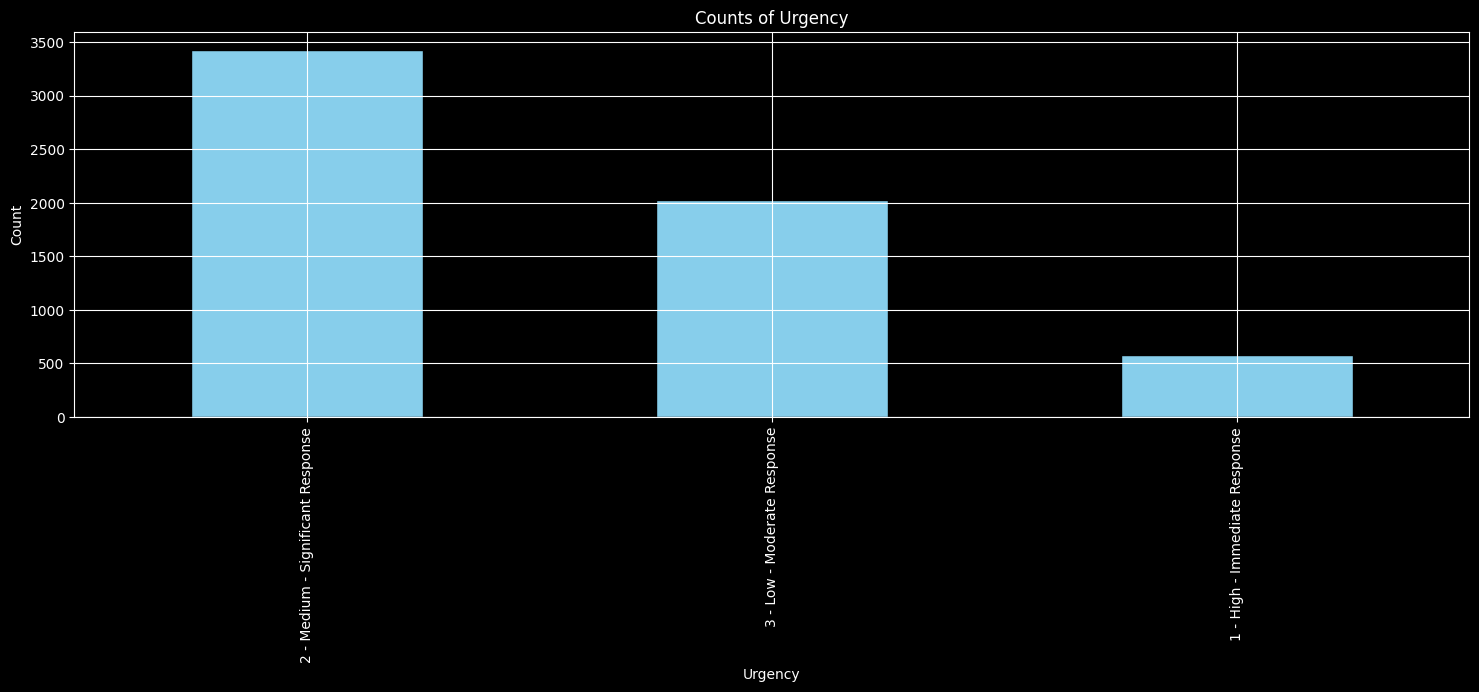

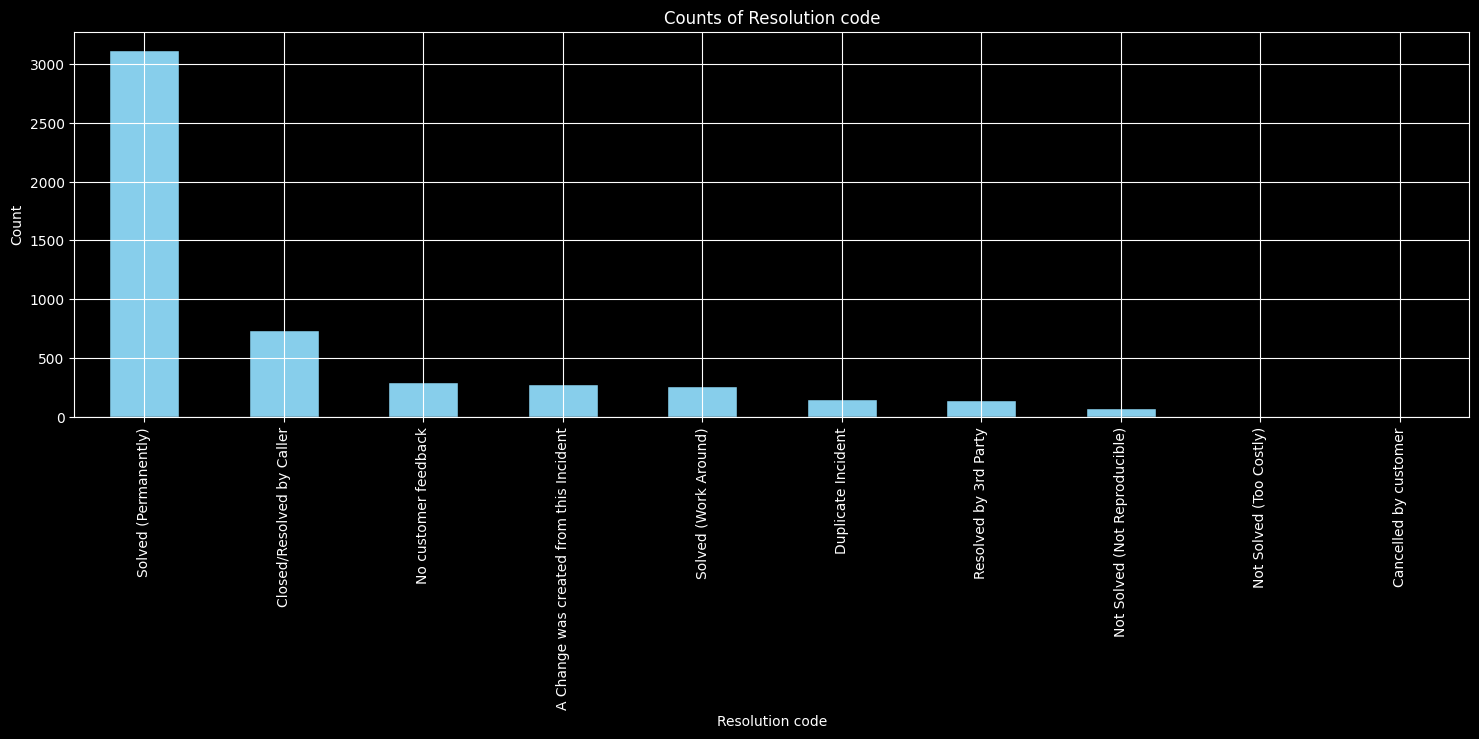

In [ ]:
plot_these_cols = ["Company", "Category", "Impact", "Urgency", "Resolution code"]

for c in plot_these_cols:
    plot_simple_bar(df_inc, c, c)

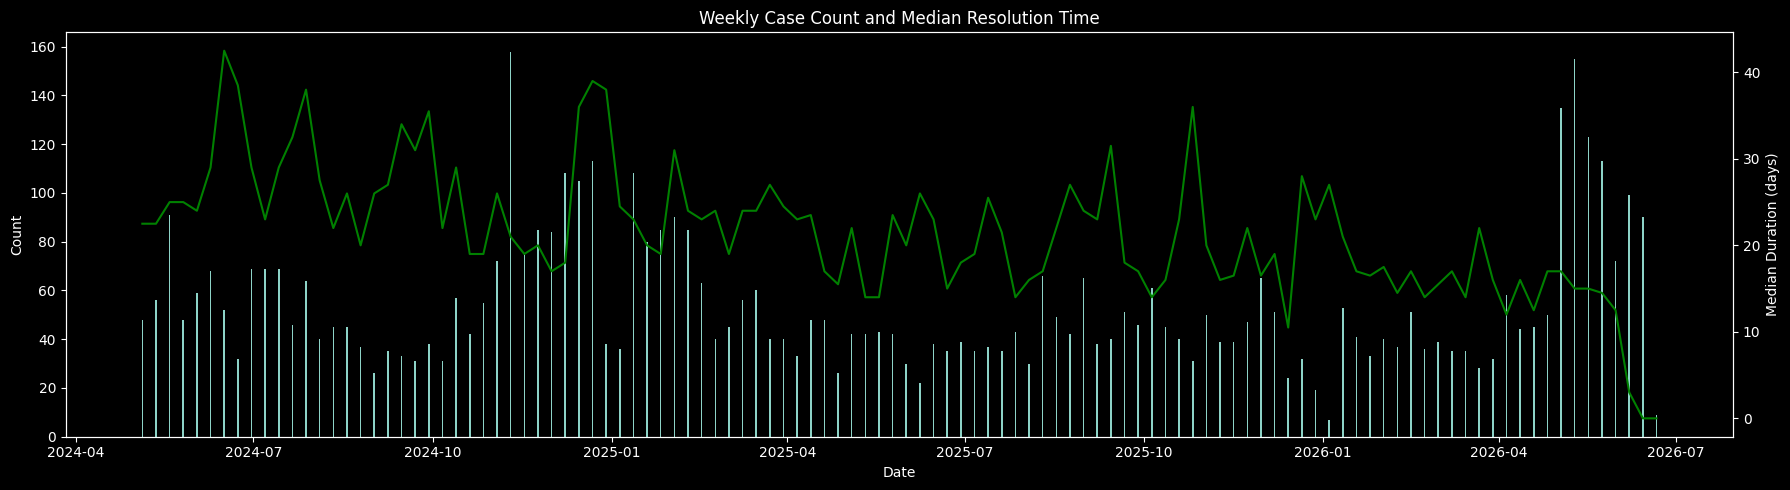

In [ ]:
# ensure datetime
df_inc["Opened"] = pd.to_datetime(df_inc["Opened"])
df_inc["Closed"] = pd.to_datetime(df_inc["Closed"])

# duration in days
df_inc["Duration"] = (df_inc["Closed"] - df_inc["Opened"]).dt.days

# weekly aggregations
weekly_count = (
    df_inc.set_index("Opened")
    .resample("W")
    .size()
)

weekly_duration = (
    df_inc.set_index("Opened")
    .resample("W")["Duration"]
    .median()
)

fig, ax1 = plt.subplots(figsize=(18, 5))

# bars = count
ax1.bar(weekly_count.index, weekly_count.values)
ax1.set_ylabel("Count")
ax1.set_xlabel("Date")

# second axis = duration
ax2 = ax1.twinx()
ax2.plot(weekly_duration.index, weekly_duration.values, color="green")
ax2.set_ylabel("Median Duration (days)")


plt.xticks(rotation=90)
plt.title("Weekly Case Count and Median Resolution Time")

plt.tight_layout()
plt.show()

## Incident SLA

In [ ]:
df_inc_sla.head(3)

column,Number,Company,Business service,Assigned to,State,Target,Stage,Business elapsed time,Actual elapsed time,Has breached,SLA definition,Business time left,Business elapsed percentage,Start time,Stop time,Breach time,Original breach time,Actual elapsed percentage,Actual end,Actual start,Actual time left,Business duration,Business pause duration,Business resolve time,Total business elapsed time
0,INC0031096,2M Holdings Limited,2M FO Support,Lakshmi Mula,Resolved,Resolution,Paused,15468,15468,False,NoSLA Rsv-P4-5D-WD 0900 1730 LON-UK Hol,137532,10.11,2025-03-06 10:43:22,NaT,2025-03-13 10:43:22,2025-03-13 10:43:22,2.56,NaT,NaN,589332,57600.0,NaN,57600.0,NaN
1,INC0032855,ACCA,ACCA FO Support,Rochelle Peralta Perez,On Hold,Resolution,Paused,44651,48917,True,Rsv-P2-6H-WD 0800 1800 LON-UK Hol,0,206.72,2026-02-09 15:12:46,NaT,2026-03-05 10:23:08,2026-02-10 11:12:46,0.65,NaT,NaN,0,NaN,3100983.0,NaN,386758.0
2,INC0034834,ACCA,ACCA FO Support,Lalit Murlidhar Jivnani,On Hold,Resolution,Paused,2069,5403,False,Rsv-P4-50H-WD 0800 1800 LON-UK Hol,177931,1.15,2026-05-20 18:13:08,NaT,2026-06-08 09:18:08,2026-05-28 18:13:08,0.89,NaT,NaN,602731,NaN,219900.0,NaN,2069.0


## Problem tickets

In [ ]:
df_prob.head(3)

column,Active,Number,Company,Business service,Short description,State,Assignment group,Assigned to,Problem owner,Configuration item,Related Incidents,Opened,Updated,Updated by
0,True,PRB0040273,Iceland Foods,Iceland Foods FO Support,Issue with OCR invoice - net value column is zero,New,FO Iceland Foods Agents,Uddipta Bhattacharya,NaN,NaN,0,2026-06-15 10:22:23,2026-06-15 10:24:07,rosie.huckle
1,False,PRB0040272,Iceland Foods,Iceland Foods FO Support,Azure Timeouts are preventing all integrations...,Resolved,FO Iceland Foods Agents,Richard Hims,Paul Caruana,NaN,0,2026-06-02 08:20:44,2026-06-04 15:01:29,rosie.huckle
2,True,PRB0040271,Leeds City Council,Leeds Power Platform Support,Error message in Power App and F&O sync,Resolved,Power Platform Leeds Agents,Vikranth B,Paul Caruana,Power App: My Finance Approvals,1,2026-06-01 13:24:39,2026-06-12 13:23:47,paul.caruana


## Service Requests

In [ ]:
df_sr.head(3)

column,Number,Created,Requested for,Company,Business service,Request item,Item,Priority,Short description,State,Assignment group,Assigned to,Updated,Updated by,Closed
0,SCTASK0012980,2024-05-01 15:18:45,Said Olar,Smart Metering Systems,SMS FO Support,RITM0014146,Raise a Request,3 - Moderate,Invoice Branding - Custom Fonts For Use In AR ...,Closed Complete,FO SMS Agents,Mario Gauci,2024-07-11 14:51:24,mario.gauci,2024-07-11 14:51:24
1,SCTASK0012983,2024-05-02 15:15:32,Ross West,KPMG Ireland,KPMG Ireland CE Support,RITM0014149,Raise a Request,4 - Low,CRM Request: Solution Investigation on Offerin...,Closed Complete,CE KPMG Ireland Agents,Lisa Court,2025-07-16 12:15:22,lisa.court,2025-07-16 12:15:18
2,SCTASK0012984,2024-05-02 15:51:52,Ross West,KPMG Ireland,KPMG Ireland CE Support,RITM0014150,Raise a Request,2 - High,CRM CR - Admin Data Investigation on User Acti...,Closed Complete,CE KPMG Ireland Agents,Marco Mizzi,2025-07-16 14:04:30,marco.mizzi,2025-07-16 12:40:24


## Time Card Joined with Pods

In [ ]:
df_pods.head(3)

column,Group,User,Email,Specialisation
0,Pod FO 1 Technical,Lakshmi Mula,Lakshmi.Mula@KPMG.co.uk,FO Technical
1,Pod FO 3 Technical,Lalit Murlidhar Jivnani,LalitMurlidhar.Jivnani@kpmg.co.uk,FO Technical
2,Pod FO 2 Technical,Sumukh VeachamRamkumar,Sumukh.VeachamRamkumar@kpmg.co.uk,FO Technical


In [ ]:
df_pods.shape

(81, 4)

In [ ]:
df_time.head(3)

column,Date,User,Task,Company,Category,Time worked,Rate type
0,2024-05-01,Valentina Sabogal Gonzalez,NaN,NaN,Sick/Holiday,8.0,Normal Billable
1,2024-05-01,Uzair Mansuri,SCTASK0012943,AIB life,Task work,2.0,Overtime Billable
2,2024-05-01,Clayton Saliba,NaN,NaN,Sick/Holiday,8.0,Normal Billable


In [ ]:
df_time.shape

(100000, 7)

In [ ]:
df_time_pod = df_time.merge(df_pods[["User", "Group"]], on="User", how="outer")

df_time_pod.shape

(100022, 8)

In [ ]:
users_not_in_time = df_pods.loc[~df_pods["User"].isin(df_time["User"]), "User"].unique()
df_not_in_time = pd.DataFrame(users_not_in_time, columns=["User"])

Likely because some people purposefully don't have pods assigned to them

In [ ]:
df_not_in_time.shape

(22, 1)

In [ ]:
df_time_pod.head(3)

column,Date,User,Task,Company,Category,Time worked,Rate type,Group
0,NaT,Abbas Ali Aloc,NaN,NaN,NaN,NaN,NaN,Pod Data
1,2024-11-25,Abdul Rahman,GEN0010412,2M Holdings Limited,Task work,3.0,Normal Billable,NaN
2,2024-11-25,Abdul Rahman,GEN0010412,2M Holdings Limited,Task work,1.0,Normal Billable,NaN


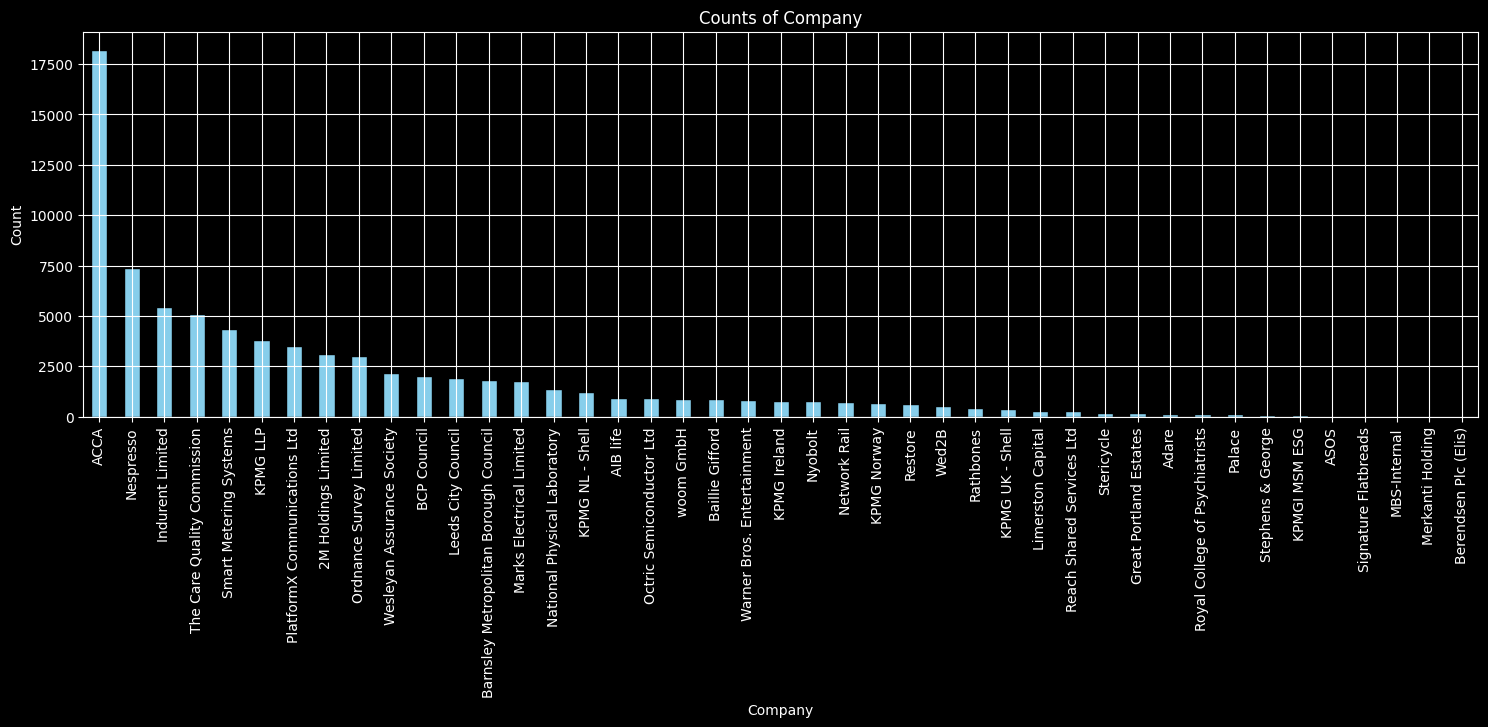

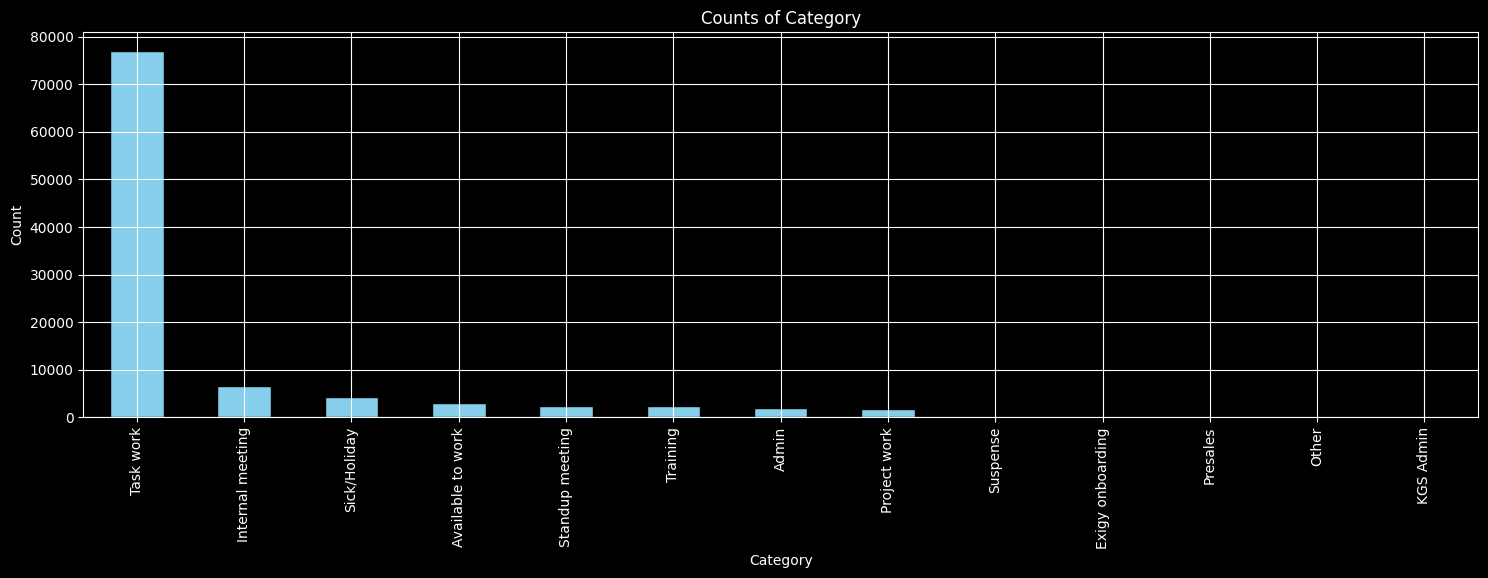

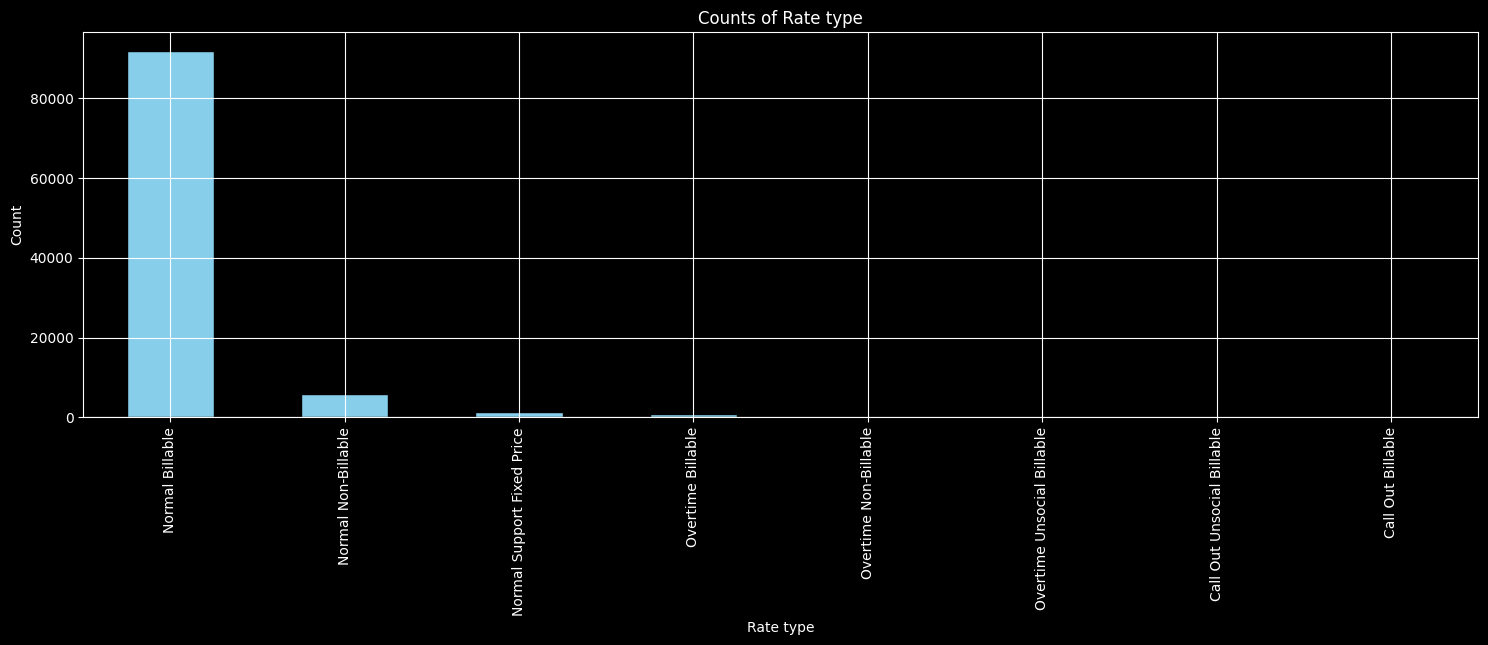

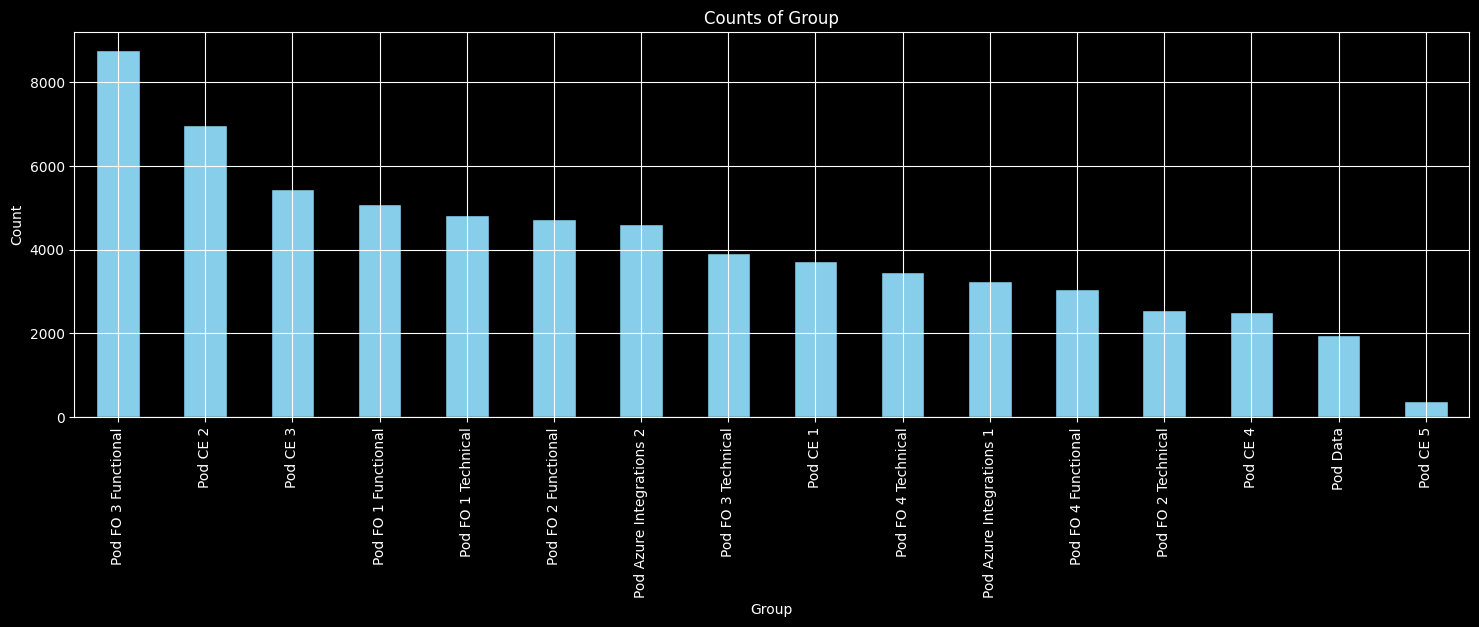

In [ ]:
plot_these_cols = ["Company", "Category", "Rate type", "Group"]

for c in plot_these_cols:
    plot_simple_bar(df_time_pod, c, c)

Check time worked distributed by pods to check if time is evenly distributed

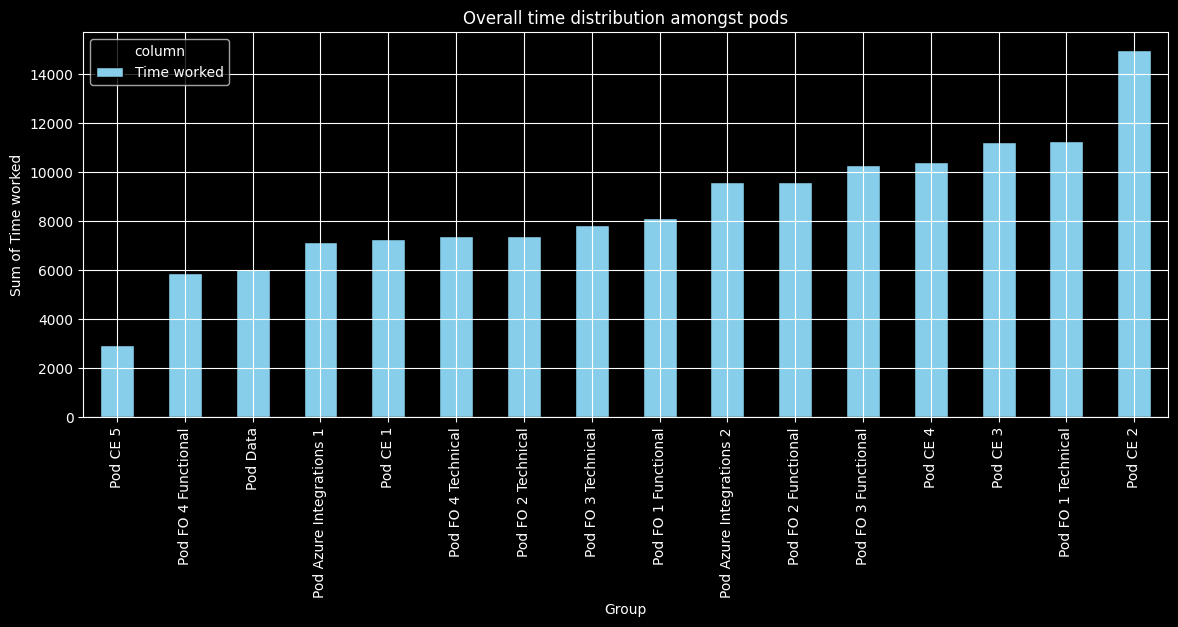

In [ ]:
df_time_pod.groupby("Group")\
    .sum("Time worked")\
    .sort_values(by="Time worked")\
    .plot(kind="bar", figsize=(14,5), color="skyblue", edgecolor="black")
plt.title("Overall time distribution amongst pods")
plt.style.use('dark_background')
plt.grid(True)
plt.ylabel("Sum of Time worked")
plt.show()

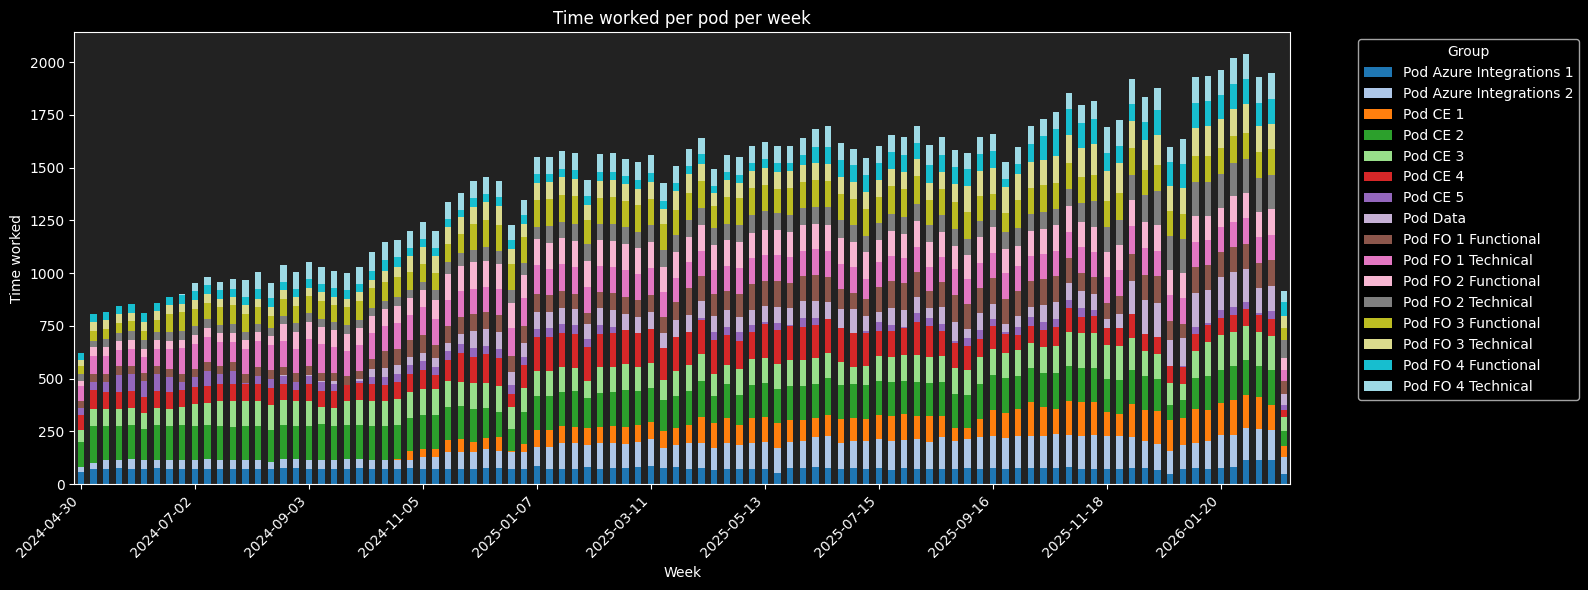

In [ ]:
df_time_pod["week"] = (
    pd.to_datetime(df_time_pod["Date"])
    .dt.to_period("W-MON")
    .dt.start_time
)

# Aggregate properly
df_weekly = (
    df_time_pod
    .groupby(["week", "Group"])["Time worked"]
    .sum()
    .unstack()
    .sort_index()
)

# Plot with softer colors
ax = df_weekly.plot(
    kind="bar",
    stacked=True,
    figsize=(16, 6),
    colormap="tab20",
    edgecolor="none"
)

# Reduce number of x-axis labels (show every 2nd or 3rd)
step = max(1, len(df_weekly.index) // 10)
ax.set_xticks(range(0, len(df_weekly.index), step))
ax.set_xticklabels(
    df_weekly.index[::step].strftime("%Y-%m-%d"),
    rotation=45,
    ha="right"
)
ax.set_facecolor("#222222") 
plt.style.use('dark_background')

plt.title("Time worked per pod per week")
plt.xlabel("Week")
plt.ylabel("Time worked")
plt.legend(title="Group", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


Find discrepancy between pods

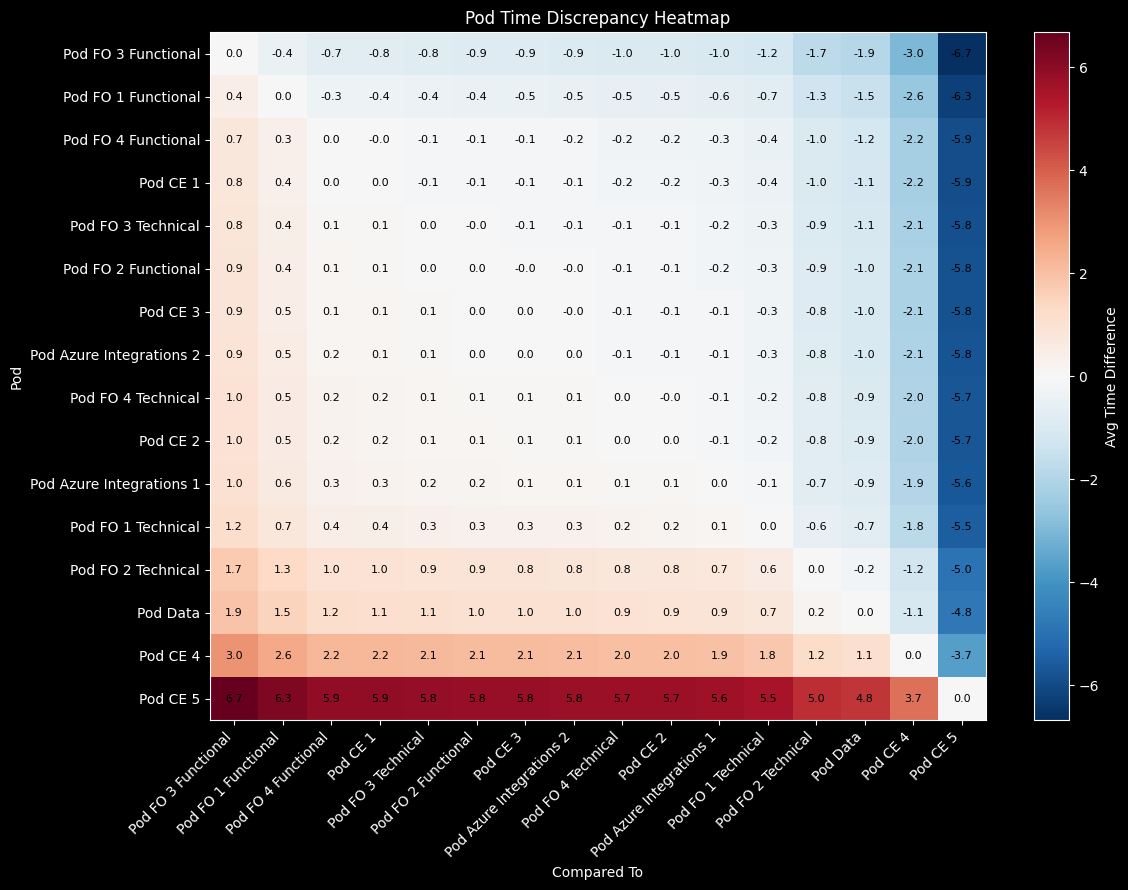

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Step 1: Average time per pod
pod_avg = (
    df_time_pod
    .groupby("Group")["Time worked"]
    .mean()
    .sort_values()
)

# Step 2: Build discrepancy matrix
pods = pod_avg.index
matrix = pd.DataFrame(index=pods, columns=pods, dtype=float)

for g1 in pods:
    for g2 in pods:
        matrix.loc[g1, g2] = pod_avg[g1] - pod_avg[g2]

# Step 3: Plot heatmap
plt.figure(figsize=(12, 9))

heatmap = plt.imshow(matrix, cmap="RdBu_r", aspect="auto")  # softer diverging palette
plt.colorbar(heatmap, label="Avg Time Difference")

# Labels
plt.xticks(ticks=np.arange(len(pods)), labels=pods, rotation=45, ha="right")
plt.yticks(ticks=np.arange(len(pods)), labels=pods)

plt.title("Pod Time Discrepancy Heatmap")
plt.xlabel("Compared To")
plt.ylabel("Pod")

# Annotate values (optional but useful)
for i in range(len(pods)):
    for j in range(len(pods)):
        plt.text(j, i, f"{matrix.iloc[i, j]:.1f}",
                 ha="center", va="center", fontsize=8, color="black")

plt.tight_layout()
plt.show()

In totality, Pod CE 5 is underutilized compared to all other pods. Otherwise, the discrepancy between pod workloads are fairly minimal.

Next, look at distribution of time on non-project related tasks

In [ ]:
df_time_pod.head(2)

column,Date,User,Task,Company,Category,Time worked,Rate type,Group,week
0,NaT,Abbas Ali Aloc,NaN,NaN,NaN,NaN,NaN,Pod Data,NaT
1,2024-11-25,Abdul Rahman,GEN0010412,2M Holdings Limited,Task work,3.0,Normal Billable,NaN,2024-11-19


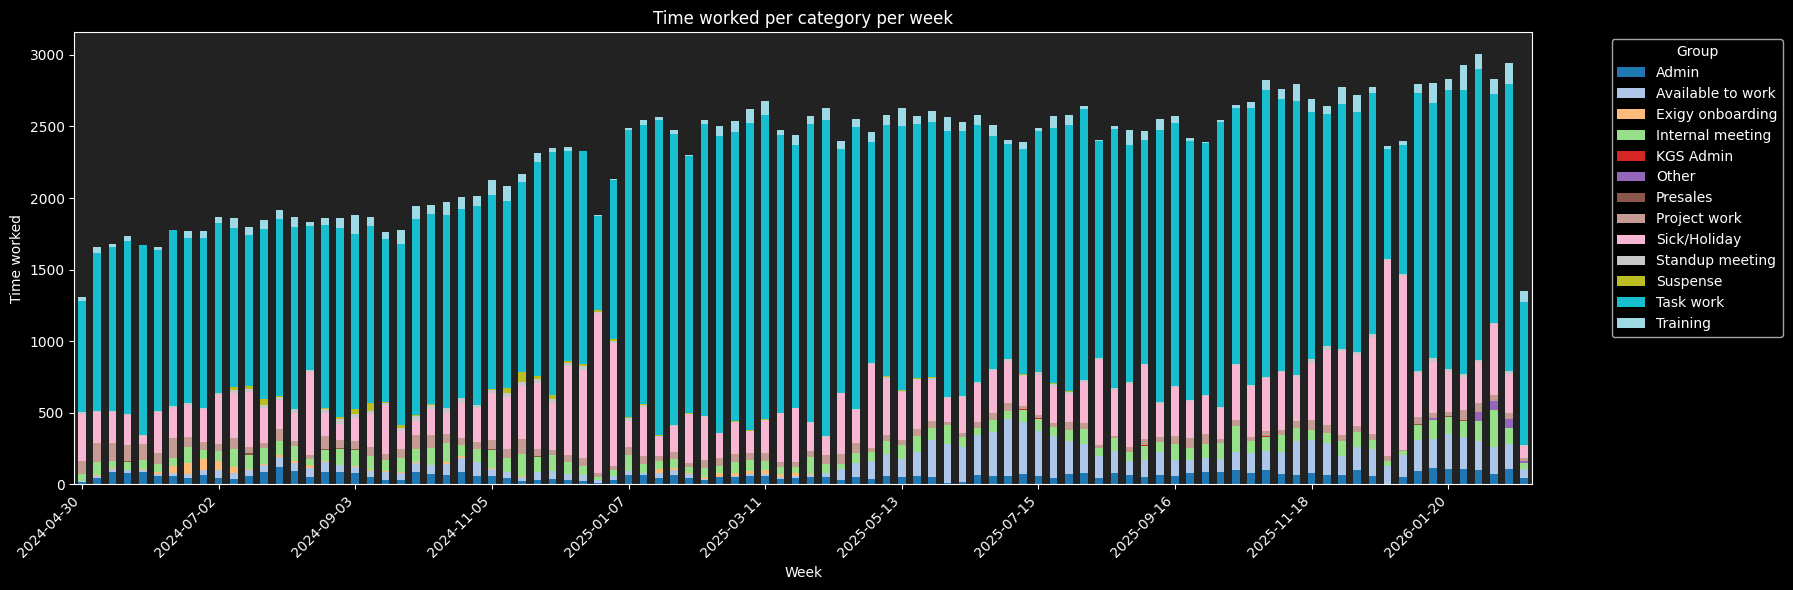

In [ ]:
df_time_pod["week"] = (
    pd.to_datetime(df_time_pod["Date"])
    .dt.to_period("W-MON")
    .dt.start_time
)

# Aggregate properly
df_weekly = (
    df_time_pod
    .groupby(["week", "Category"])["Time worked"]
    .sum()
    .unstack()
    .sort_index()
)

# Plot with softer colors
ax = df_weekly.plot(
    kind="bar",
    stacked=True,
    figsize=(18, 6),
    colormap="tab20",
    edgecolor="none"
)
ax.set_facecolor("#222222") 

# Reduce number of x-axis labels (show every 2nd or 3rd)
step = max(1, len(df_weekly.index) // 10)
ax.set_xticks(range(0, len(df_weekly.index), step))
ax.set_xticklabels(
    df_weekly.index[::step].strftime("%Y-%m-%d"),
    rotation=45,
    ha="right"
)

plt.title("Time worked per category per week")
ax.set_facecolor("#222222") 
plt.style.use('dark_background')
plt.xlabel("Week")
plt.ylabel("Time worked")
plt.legend(title="Group", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


Look at time spent on billables versus non-billables

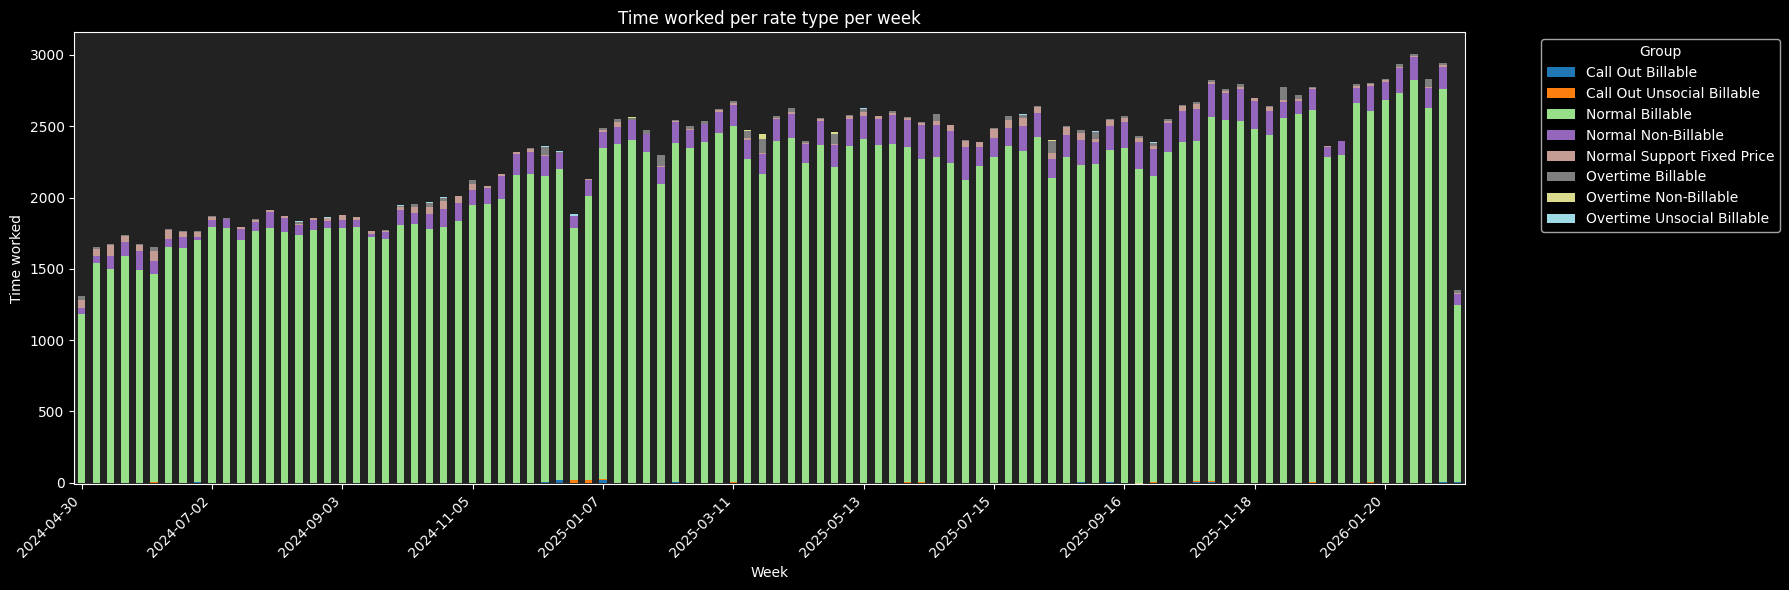

In [ ]:
df_time_pod["week"] = (
    pd.to_datetime(df_time_pod["Date"])
    .dt.to_period("W-MON")
    .dt.start_time
)

# Aggregate properly
df_weekly = (
    df_time_pod
    .groupby(["week", "Rate type"])["Time worked"]
    .sum()
    .unstack()
    .sort_index()
)

# Plot with softer colors
ax = df_weekly.plot(
    kind="bar",
    stacked=True,
    figsize=(18, 6),
    colormap="tab20",
    edgecolor="none"
)
ax.set_facecolor("#222222") 

# Reduce number of x-axis labels (show every 2nd or 3rd)
step = max(1, len(df_weekly.index) // 10)
ax.set_xticks(range(0, len(df_weekly.index), step))
ax.set_xticklabels(
    df_weekly.index[::step].strftime("%Y-%m-%d"),
    rotation=45,
    ha="right"
)

plt.title("Time worked per rate type per week")
ax.set_facecolor("#222222") 
plt.style.use('dark_background')
plt.xlabel("Week")
plt.ylabel("Time worked")
plt.legend(title="Group", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()
